<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/notebooks/extra/extra 03 - Autoencoders and VAEs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab · Autoencoders and Variational Autoencoders (VAEs)

Most data has no labels. An **autoencoder** learns from the inputs alone: an **encoder** squeezes each image into a short code $\mathbf{z}$, a **decoder** rebuilds the image from the code, and the training signal is the reconstruction error. To rebuild well from a few numbers, the code must keep what matters (which digit, slant, stroke width) and drop the rest. The same model compresses, removes noise, gives embeddings for search and clustering, and flags anomalies: inputs it cannot rebuild.

A plain autoencoder cannot **generate** new images: its code space has holes and no density to sample from. The **variational autoencoder** (VAE) makes the code a random variable with a known prior, $p(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I})$, and trains on a lower bound of the log-likelihood, the ELBO. In this lab we build both from scratch on MNIST, starting from PCA, which is the linear autoencoder.

**Contents**

1. MNIST and the reconstruction loss
2. PCA from scratch
3. The linear autoencoder learns the PCA subspace
4. A non-linear autoencoder with a 2-D code
5. Latent size, overcomplete codes and sparsity
6. Convolutional and denoising autoencoders
7. Why an autoencoder is not a generative model
8. The variational autoencoder from scratch
9. What the KL term does to the latent space
10. β-VAE, rate and distortion, posterior collapse
11. A conditional VAE
12. Practice: what to monitor
13. Summary and exercises

This lab goes with the slides *Extra 3 · Autoencoders and variational autoencoders* and uses the same notation. It assumes the neural-network part of the course: MLPs, CNNs, backpropagation, the PyTorch training loop, and cross-entropy as maximum likelihood. PCA and the KL divergence are introduced from scratch. Everything runs on a CPU in about 3 minutes with 4 CPU threads (a few more on a 2-core Colab CPU); a GPU is not needed.

**Notation**

| Symbol | Meaning |
|---|---|
| $\mathbf{x} \in [0, 1]^D$, $D = 784$ | one image as a vector of pixels (1 = black ink); $\mathbf{X}$ ($n \times D$) has **one image per row** |
| $\mathbf{z} \in \mathbb{R}^k$ | the code (latent vector); $k$ = latent size, the bottleneck |
| $f_\phi$, $g_\theta$ | encoder and decoder, $\hat{\mathbf{x}} = g_\theta(f_\phi(\mathbf{x}))$ |
| $\boldsymbol{\mu}$, $\mathbf{X}_c$ | mean image, centred data $\mathbf{X}_c = \mathbf{X} - \mathbf{1}\boldsymbol{\mu}^\top$ |
| $\mathbf{C} = \frac{1}{n}\mathbf{X}_c^\top\mathbf{X}_c$ | covariance matrix; eigenvalues $\lambda_1 \ge \dots \ge \lambda_D$, eigenvectors $\mathbf{v}_j$ (principal components) |
| $\mathbf{V}_k$ | $D \times k$ matrix of the top-$k$ principal components; codes $\mathbf{Z} = \mathbf{X}_c\mathbf{V}_k$ |
| $p(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I})$ | prior over codes |
| $p_\theta(\mathbf{x} \mid \mathbf{z})$ | decoder as a likelihood (Bernoulli pixels in this lab) |
| $q_\phi(\mathbf{z} \mid \mathbf{x}) = \mathcal{N}(\boldsymbol{\mu}_\phi(\mathbf{x}), \operatorname{diag}\boldsymbol{\sigma}^2_\phi(\mathbf{x}))$ | encoder as an approximate posterior |
| $\mathrm{KL}(q \,\Vert\, p)$ | Kullback–Leibler divergence $\mathbb{E}_q[\log q - \log p] \ge 0$ |
| $\mathcal{L}(\mathbf{x}) \le \log p_\theta(\mathbf{x})$ | ELBO (evidence lower bound), in nats |
| $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ | noise of the reparameterisation $\mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \boldsymbol{\epsilon}$ |
| $\beta$ | weight of the KL term (β-VAE); $\beta = 1$ is the ELBO |

In [1]:
import contextlib, io, math, time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from scipy import integrate, stats
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
np.set_printoptions(precision=3, suppress=True)
np.random.seed(0); torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| torch", torch.__version__, "| torchvision", torchvision.__version__,
      "| CPU threads:", torch.get_num_threads())
T_START = time.time()

device: cpu | torch 2.12.0+cu130 | torchvision 0.27.0+cu130 | CPU threads: 4


## 1. MNIST and the reconstruction loss

MNIST: 70,000 handwritten digits of $28 \times 28$ grey pixels, 60,000 for training and 10,000 for testing. Each image becomes a vector $\mathbf{x} \in [0, 1]^{784}$, and the images are the rows of $\mathbf{X}$. The labels are used only to colour plots and to judge results, never to train an autoencoder (except the conditional VAE of section 11).

An **autoencoder** is two networks trained together,

$$
\mathbf{z} = f_\phi(\mathbf{x}) \in \mathbb{R}^k \quad \text{(encoder)}, \qquad \hat{\mathbf{x}} = g_\theta(\mathbf{z}) \in \mathbb{R}^D \quad \text{(decoder)},
$$

so that $\hat{\mathbf{x}}$ is close to $\mathbf{x}$. With $k < D$ (**undercomplete**) the code is a **bottleneck**: the network cannot copy its input, it has to compress it.

train: (60000, 784)  test: (10000, 784)   (expected (60000, 784) and (10000, 784))


pixel range [0, 1], mean pixel 0.131, fraction of pixels that are exactly 0: 0.809


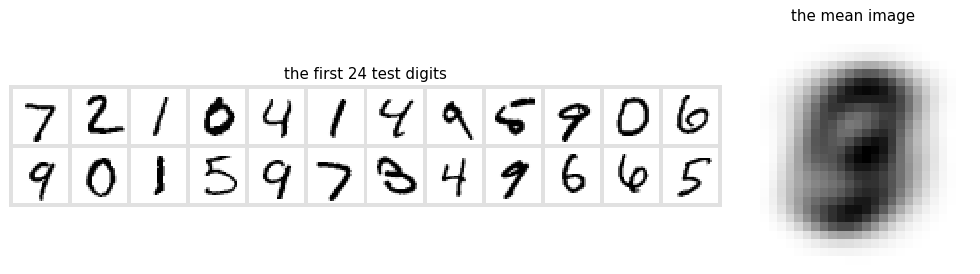

In [2]:
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):   # hide download progress bars
    mnist_train = torchvision.datasets.MNIST("data", train=True, download=True)
    mnist_test = torchvision.datasets.MNIST("data", train=False, download=True)
X_train = (mnist_train.data.reshape(-1, 784).float() / 255).to(device)    # one row per image, pixels in [0, 1]
y_train = mnist_train.targets.to(device)
X_test = (mnist_test.data.reshape(-1, 784).float() / 255).to(device)
y_test = mnist_test.targets.to(device)
n, D = X_train.shape


def mosaic(X, ncol, pad=2, fill=0.12):
    """Tile images (rows of 784 pixels) into one array, ncol images per row, separated by light grey gaps."""
    X = np.asarray(torch.as_tensor(X).detach().cpu()).reshape(-1, 28, 28)
    nrow = math.ceil(len(X) / ncol)
    M = np.full((nrow * (28 + pad) + pad, ncol * (28 + pad) + pad), fill)
    for i, img in enumerate(X):
        r, c = divmod(i, ncol)
        M[pad + r * (28 + pad): pad + r * (28 + pad) + 28, pad + c * (28 + pad): pad + c * (28 + pad) + 28] = img
    return M


def show(ax, X, ncol, title=""):
    """Draw a mosaic of digits, dark ink on white (pixel value 1 = black)."""
    ax.imshow(mosaic(X, ncol), cmap="gray_r", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title); ax.axis("off"); ax.grid(False)


print("train:", tuple(X_train.shape), " test:", tuple(X_test.shape), "  (expected (60000, 784) and (10000, 784))")
print(f"pixel range [{X_train.min():.0f}, {X_train.max():.0f}], mean pixel {X_train.mean():.3f}, "
      f"fraction of pixels that are exactly 0: {(X_train == 0).float().mean():.3f}")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), gridspec_kw={"width_ratios": [3, 1]})
show(axes[0], X_test[:24], 12, "the first 24 test digits")
axes[1].imshow(X_train.mean(0).reshape(28, 28).cpu(), cmap="gray_r"); axes[1].axis("off"); axes[1].set_title("the mean image")
plt.tight_layout(); plt.show()

**Which reconstruction loss?** As everywhere in the course, a loss is a negative log-likelihood. Read the decoder output as the parameters of a distribution over images, $p_\theta(\mathbf{x} \mid \mathbf{z})$, and minimise $-\log p_\theta(\mathbf{x} \mid \mathbf{z})$.

- **Gaussian pixels**, $p(\mathbf{x} \mid \mathbf{z}) = \mathcal{N}(\mathbf{x};\, \hat{\mathbf{x}}, \sigma^2\mathbf{I})$:
$$
-\log p(\mathbf{x} \mid \mathbf{z}) = \frac{1}{2\sigma^2}\lVert \mathbf{x} - \hat{\mathbf{x}} \rVert^2 + \frac{D}{2}\log(2\pi\sigma^2).
$$
With $\sigma$ fixed the second term is a constant, so this is the **squared error** (MSE) up to a scale.
- **Bernoulli pixels**, each pixel black with probability $\hat x_j$: $p(\mathbf{x} \mid \mathbf{z}) = \prod_j \hat x_j^{\,x_j}(1 - \hat x_j)^{1 - x_j}$, so
$$
-\log p(\mathbf{x} \mid \mathbf{z}) = -\sum_{j=1}^{D} \big[x_j \log \hat x_j + (1 - x_j)\log(1 - \hat x_j)\big],
$$
the **binary cross-entropy** (BCE), with a sigmoid on the decoder output, exactly as in logistic regression.

The loss is a choice of noise model. MSE assumes Gaussian errors of the same size on every pixel; BCE assumes black-or-white pixels and punishes a confident wrong pixel much harder. Both are minimal at $\hat{\mathbf{x}} = \mathbf{x}$. We check the two formulas on one digit.

Gaussian : -log N(x | x_hat, 0.1² I) =   -719.18   SSE / (2σ²) + (D/2) log(2πσ²) =   -719.18
Bernoulli: -log Bern(x | x_hat)       =    102.12   BCE summed over the 784 pixels  =    102.12
BCE of a grey-level digit with itself = 40.97 nats: the minimum is at x_hat = x, but it is not 0


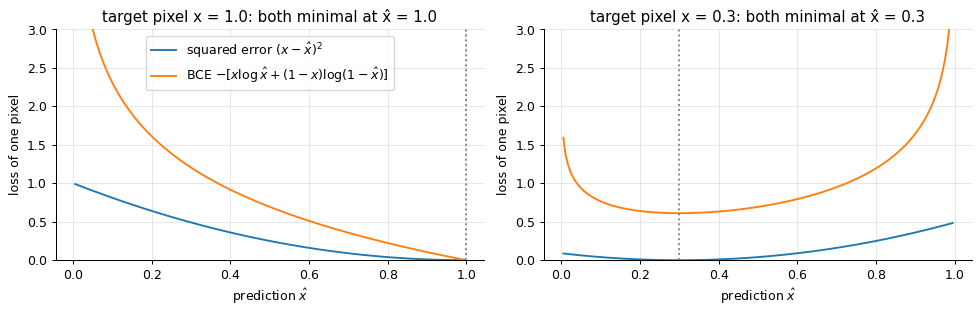

In [3]:
x = X_test[0]
x_hat = (0.8 * x + 0.1).clamp(1e-3, 1 - 1e-3)          # a deliberately imperfect "reconstruction" of digit 0
sigma = 0.1
nll_gauss = -torch.distributions.Normal(x_hat, sigma).log_prob(x).sum()
formula_mse = ((x - x_hat) ** 2).sum() / (2 * sigma**2) + D / 2 * math.log(2 * math.pi * sigma**2)
x_bw = (x > 0.5).float()                                 # a black-and-white version of the same digit
nll_bern = -torch.distributions.Bernoulli(probs=x_hat).log_prob(x_bw).sum()
formula_bce = F.binary_cross_entropy(x_hat, x_bw, reduction="sum")
print(f"Gaussian : -log N(x | x_hat, 0.1² I) = {nll_gauss:9.2f}   SSE / (2σ²) + (D/2) log(2πσ²) = {formula_mse:9.2f}")
print(f"Bernoulli: -log Bern(x | x_hat)       = {nll_bern:9.2f}   BCE summed over the 784 pixels  = {formula_bce:9.2f}")
assert torch.isclose(nll_gauss, formula_mse, rtol=1e-5) and torch.isclose(nll_bern, formula_bce, rtol=1e-5)
bce_self = F.binary_cross_entropy(x.clamp(1e-6, 1 - 1e-6), x, reduction="sum")
print(f"BCE of a grey-level digit with itself = {bce_self:.2f} nats: the minimum is at x_hat = x, but it is not 0")

p = np.linspace(0.005, 0.995, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, t in zip(axes, [1.0, 0.3]):
    ax.plot(p, (p - t) ** 2, label=r"squared error $(x-\hat x)^2$")
    ax.plot(p, -(t * np.log(p) + (1 - t) * np.log(1 - p)), label=r"BCE $-[x\log\hat x+(1-x)\log(1-\hat x)]$")
    ax.axvline(t, color="gray", ls=":")
    ax.set_xlabel(r"prediction $\hat x$"); ax.set_ylabel("loss of one pixel"); ax.set_ylim(0, 3)
    ax.set_title(f"target pixel x = {t}: both minimal at x̂ = {t}")
axes[0].legend()
plt.tight_layout(); plt.show()

**What just happened?**
- Both identities hold to the last digit. The Gaussian negative log-likelihood (−719.18, negative because a density can exceed 1) is the squared error divided by $2\sigma^2$ plus a constant, and the Bernoulli one (102.12 nats) is the BCE summed over the 784 pixels. Training with MSE or with BCE **is** maximum likelihood, under two different noise models.
- 81% of the MNIST pixels are exactly 0 (white background) and most of the others are close to 1: the data is almost black and white, which suits the Bernoulli model. We use MSE for the autoencoders of sections 2 to 7 (to compare with PCA, which minimises squared error) and BCE for the VAEs.
- With grey targets the BCE of a perfect reconstruction is not 0 but the entropy of the pixels (40.97 nats for digit 0). Only differences between BCE values mean something; section 8 avoids the issue by binarising the digits.

## 2. PCA from scratch

**Principal component analysis** is the oldest autoencoder: a linear encoder and a linear decoder.

Centre the data, $\mathbf{X}_c = \mathbf{X} - \mathbf{1}\boldsymbol{\mu}^\top$, and form the **covariance matrix**

$$
\mathbf{C} = \frac{1}{n}\mathbf{X}_c^\top\mathbf{X}_c \in \mathbb{R}^{D \times D}, \qquad C_{ij} = \text{covariance of pixels } i \text{ and } j .
$$

Encode an image by its coordinate along one unit vector $\mathbf{w}$, $z = (\mathbf{x} - \boldsymbol{\mu})^\top\mathbf{w}$, and decode with $\hat{\mathbf{x}} = \boldsymbol{\mu} + z\,\mathbf{w}$. Which $\mathbf{w}$ is best?

- The variance of the codes is $\frac{1}{n}\sum_i z_i^2 = \mathbf{w}^\top\mathbf{C}\mathbf{w}$.
- $\hat{\mathbf{x}} - \boldsymbol{\mu}$ is the orthogonal projection of $\mathbf{x} - \boldsymbol{\mu}$ on the line, so by Pythagoras $\lVert \mathbf{x} - \boldsymbol{\mu} \rVert^2 = z^2 + \lVert \mathbf{x} - \hat{\mathbf{x}} \rVert^2$. Averaged over the data:
$$
\underbrace{\frac{1}{n}\sum_i \lVert \mathbf{x}_i - \hat{\mathbf{x}}_i \rVert^2}_{\text{mean squared error}} = \underbrace{\operatorname{tr}\mathbf{C}}_{\text{total variance}} - \underbrace{\mathbf{w}^\top\mathbf{C}\mathbf{w}}_{\text{variance kept}} .
$$

**Minimum error = maximum variance.** Maximise $\mathbf{w}^\top\mathbf{C}\mathbf{w}$ subject to $\mathbf{w}^\top\mathbf{w} = 1$. The gradient of the Lagrangian $\mathbf{w}^\top\mathbf{C}\mathbf{w} - \lambda(\mathbf{w}^\top\mathbf{w} - 1)$ is $2\mathbf{C}\mathbf{w} - 2\lambda\mathbf{w}$, zero when $\mathbf{C}\mathbf{w} = \lambda\mathbf{w}$: $\mathbf{w}$ is an **eigenvector** of $\mathbf{C}$, and the variance it keeps is $\mathbf{w}^\top\mathbf{C}\mathbf{w} = \lambda$. So take the eigenvector of the largest eigenvalue. With $k$ orthogonal directions the same argument gives the top-$k$ eigenvectors $\mathbf{v}_1, \dots, \mathbf{v}_k$, the **principal components** (PCs):

$$
\mathbf{z} = \mathbf{V}_k^\top(\mathbf{x} - \boldsymbol{\mu}), \qquad \hat{\mathbf{x}} = \boldsymbol{\mu} + \mathbf{V}_k\mathbf{z}, \qquad \text{mean squared error} = \sum_{j > k}\lambda_j .
$$

For the whole data set (one image per row), $\mathbf{Z} = \mathbf{X}_c\mathbf{V}_k$ and $\hat{\mathbf{X}} = \mathbf{1}\boldsymbol{\mu}^\top + \mathbf{Z}\mathbf{V}_k^\top$. The share $\lambda_j / \sum_i \lambda_i$ is the **explained variance** of component $j$.

**Worked example** (the same six points as in the slides): $(1,1), (1,4), (3,3), (3,6), (4,4), (6,6)$. The mean is $(3, 4)$, the covariance $\begin{pmatrix} 3 & 2 \\ 2 & 3 \end{pmatrix}$, its eigenvalues $5$ and $1$, the first component $\mathbf{v}_1 = (1, 1)/\sqrt{2}$. One number per point keeps $5/6 = 83\%$ of the variance, and the mean squared error is the discarded eigenvalue, 1.

mean: [3. 4.]    covariance C = [[3.0, 2.0], [2.0, 3.0]]
eigenvalues: [5. 1.] (expected 5 and 1)   first PC v1 = [0.707 0.707] (expected (0.707, 0.707))
codes z = (x - mean) · v1: [-3.536 -1.414 -0.707  1.414  0.707  3.536]
variance of the codes = 5.000 (= λ1)   mean squared error = 1.000 (= λ2)   explained variance λ1 / (λ1 + λ2) = 0.833
point (1, 1) -> code -3.536 -> reconstruction [0.5 1.5]    squared error 0.5
SVD of the centred data: s_j² / n = [5. 1.]   |first right singular vector| = [0.707 0.707]


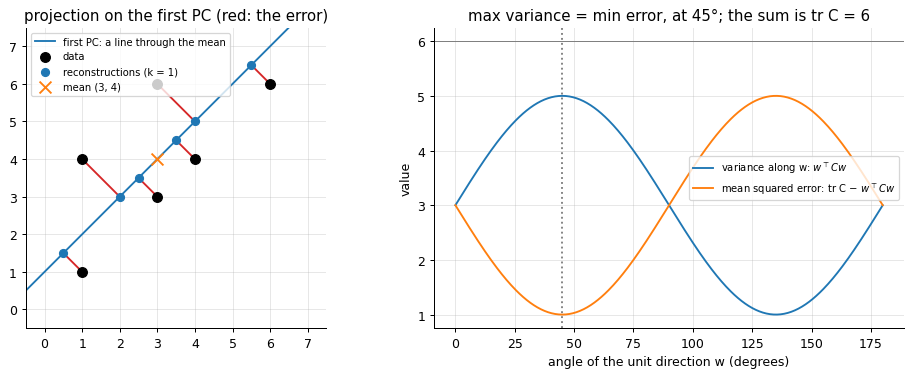

In [4]:
P = np.array([[1, 1], [1, 4], [3, 3], [3, 6], [4, 4], [6, 6]], dtype=float)   # the 6 points of the slides
m = P.mean(0)
Pc = P - m                                       # centre the data
C2 = Pc.T @ Pc / len(P)                          # covariance, divided by n
lam2, V2 = np.linalg.eigh(C2)                    # eigh returns ascending order: flip it
lam2, V2 = lam2[::-1], V2[:, ::-1]
V2 = V2 * np.sign(V2[0])                         # sign convention: first coordinate positive
z2 = Pc @ V2[:, 0]                               # 1-D codes
P_hat = m + np.outer(z2, V2[:, 0])               # reconstructions from k = 1 component
err = ((P - P_hat) ** 2).sum(1)
print("mean:", m, "   covariance C =", C2.tolist())
print("eigenvalues:", lam2, "(expected 5 and 1)   first PC v1 =", V2[:, 0], "(expected (0.707, 0.707))")
print("codes z = (x - mean) · v1:", z2.round(3))
print(f"variance of the codes = {z2.var():.3f} (= λ1)   mean squared error = {err.mean():.3f} (= λ2)   "
      f"explained variance λ1 / (λ1 + λ2) = {lam2[0] / lam2.sum():.3f}")
print("point (1, 1) -> code", round(z2[0], 3), "-> reconstruction", P_hat[0], "   squared error", err[0])
U2, S2, Vt2 = np.linalg.svd(Pc, full_matrices=False)
print("SVD of the centred data: s_j² / n =", (S2**2 / len(P)).round(6), "  |first right singular vector| =", np.abs(Vt2[0]).round(3))
assert np.allclose(lam2, [5, 1]) and np.isclose(z2.var(), lam2[0]) and np.isclose(err.mean(), lam2[1])
assert np.allclose(S2**2 / len(P), lam2) and np.allclose(np.abs(Vt2[0]), np.abs(V2[:, 0]))

th = np.linspace(0, 180, 361)
W_dir = np.stack([np.cos(np.radians(th)), np.sin(np.radians(th))], 1)
var_th = np.einsum("ij,jk,ik->i", W_dir, C2, W_dir)       # w^T C w for every direction
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
ax = axes[0]
t = np.array([-5.5, 5.5])
ax.plot(m[0] + t * V2[0, 0], m[1] + t * V2[1, 0], color="tab:blue", label="first PC: a line through the mean")
for a, b in zip(P, P_hat):
    ax.plot([a[0], b[0]], [a[1], b[1]], color="tab:red", lw=1.5)
ax.scatter(*P.T, s=60, color="k", zorder=3, label="data")
ax.scatter(*P_hat.T, s=40, color="tab:blue", zorder=3, label="reconstructions (k = 1)")
ax.scatter(*m, marker="x", s=90, color="tab:orange", zorder=4, label="mean (3, 4)")
ax.set_aspect("equal"); ax.set_xlim(-0.5, 7.5); ax.set_ylim(-0.5, 7.5); ax.legend(fontsize=8, loc="upper left")
ax.set_title("projection on the first PC (red: the error)")
ax = axes[1]
ax.plot(th, var_th, label=r"variance along w: $w^\top C w$")
ax.plot(th, np.trace(C2) - var_th, label=r"mean squared error: tr C − $w^\top C w$")
ax.axvline(45, color="gray", ls=":"); ax.axhline(np.trace(C2), color="gray", lw=0.8)
ax.set_xlabel("angle of the unit direction w (degrees)"); ax.set_ylabel("value"); ax.legend(fontsize=8, loc="center right")
ax.set_title("max variance = min error, at 45°; the sum is tr C = 6")
plt.tight_layout(); plt.show()

**PCA with the SVD.** Write the centred data with its singular value decomposition, $\mathbf{X}_c = \mathbf{U}\,\mathrm{diag}(s_1, \dots, s_D)\,\mathbf{V}^\top$, where $\mathbf{U}^\top\mathbf{U} = \mathbf{V}^\top\mathbf{V} = \mathbf{I}$. Then

$$
\mathbf{C} = \frac{1}{n}\mathbf{V}\,\mathrm{diag}(s_j)\,\mathbf{U}^\top\mathbf{U}\,\mathrm{diag}(s_j)\,\mathbf{V}^\top = \mathbf{V}\,\mathrm{diag}\!\Big(\frac{s_j^2}{n}\Big)\mathbf{V}^\top :
$$

the right singular vectors are the principal components and $\lambda_j = s_j^2 / n$. The SVD never forms $\mathbf{C}$, which is more accurate numerically. scikit-learn divides by $n - 1$ instead of $n$; the components and the explained-variance ratios do not change.

On MNIST, $\mathbf{X}_c$ is $60{,}000 \times 784$. We compute its SVD, check the identity "mean squared error = sum of the discarded eigenvalues" on the training set, compare with scikit-learn, and look at reconstructions as $k$ grows.

SVD of the 60000 x 784 centred matrix in 1.9 s
first eigenvalues: [5.117 3.741 3.253 2.842 2.567 2.274]   total variance tr C = 52.725
  k =  1: cumulative explained variance 0.097
  k =  2: cumulative explained variance 0.168
  k =  8: cumulative explained variance 0.437
  k = 16: cumulative explained variance 0.594
  k = 32: cumulative explained variance 0.744
  k = 64: cumulative explained variance 0.862
components needed for 90% / 95% of the variance: 87 / 154 (out of 784)


scikit-learn PCA: same explained-variance ratios (max difference 9.1e-06), same components up to sign (smallest |cos| = 0.999999)


k =  2: mean squared error per training image = 43.8669   sum of the discarded eigenvalues = 43.8670


k = 16: mean squared error per training image = 21.3976   sum of the discarded eigenvalues = 21.3976


k = 64: mean squared error per training image = 7.2786   sum of the discarded eigenvalues = 7.2785


test MSE per pixel: {2: 0.0557, 4: 0.0479, 8: 0.0374, 16: 0.0269, 32: 0.0168}


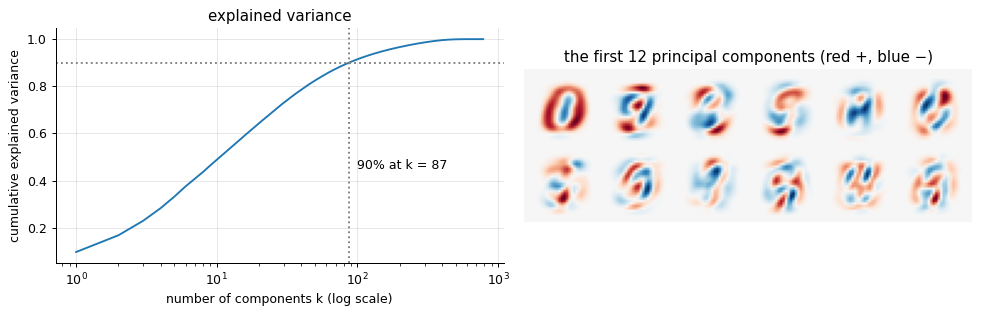

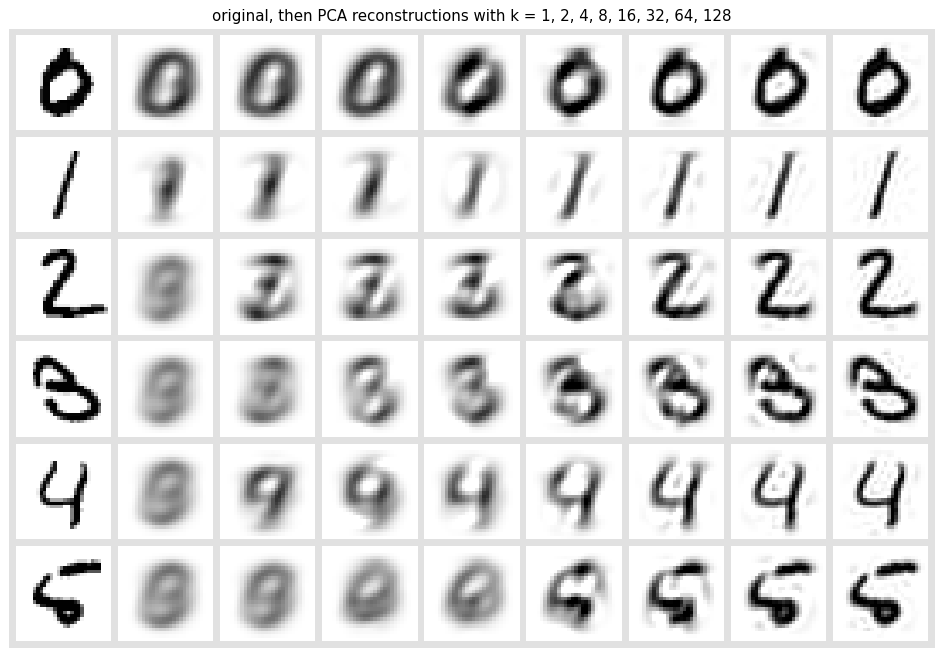

In [5]:
mu_train = X_train.mean(0)
Xc = X_train - mu_train
t0 = time.time()
U, S, Vh = torch.linalg.svd(Xc, full_matrices=False)       # Xc = U diag(S) Vh; the rows of Vh are the principal components
lam = (S**2 / n).cpu().numpy()                            # eigenvalues of C = Xc^T Xc / n
evr = lam / lam.sum()                                     # explained-variance ratios
V_pc = Vh.T                                               # D x D, column j = v_j
k90 = int(np.searchsorted(np.cumsum(evr), 0.90)) + 1
k95 = int(np.searchsorted(np.cumsum(evr), 0.95)) + 1
print(f"SVD of the 60000 x 784 centred matrix in {time.time() - t0:.1f} s")
print("first eigenvalues:", lam[:6].round(3), "  total variance tr C =", round(lam.sum(), 3))
for k in (1, 2, 8, 16, 32, 64):
    print(f"  k = {k:2d}: cumulative explained variance {evr[:k].sum():.3f}")
print(f"components needed for 90% / 95% of the variance: {k90} / {k95} (out of 784)")
sk = PCA(n_components=32, svd_solver="covariance_eigh").fit(X_train.cpu().numpy())
cos_sk = np.abs(np.sum(sk.components_ * Vh[:32].cpu().numpy(), 1))
print(f"scikit-learn PCA: same explained-variance ratios (max difference {np.abs(sk.explained_variance_ratio_ - evr[:32]).max():.1e}),"
      f" same components up to sign (smallest |cos| = {cos_sk.min():.6f})")
assert np.allclose(sk.explained_variance_ratio_, evr[:32], atol=1e-5) and cos_sk.min() > 0.999


def pca_reconstruct(X, k):
    """Project on the top-k principal components and map back: mu + (x - mu) V_k V_k^T."""
    Vk = V_pc[:, :k]
    return mu_train + (X - mu_train) @ Vk @ Vk.T


for k in (2, 16, 64):
    sse = ((pca_reconstruct(X_train, k) - X_train) ** 2).sum(1).mean().item()
    print(f"k = {k:2d}: mean squared error per training image = {sse:.4f}   sum of the discarded eigenvalues = {lam[k:].sum():.4f}")
    assert abs(sse - lam[k:].sum()) < 1e-3 * lam[k:].sum()
Zt = (X_test - mu_train) @ V_pc                           # test digits in the PC basis
pca_test_curve = ((((X_test - mu_train) ** 2).sum(1, keepdim=True) - torch.cumsum(Zt**2, 1)).mean(0) / D).cpu().numpy()
mse_pca = {k: F.mse_loss(pca_reconstruct(X_test, k), X_test).item() for k in [2, 4, 8, 16, 32]}
assert all(abs(pca_test_curve[k - 1] - v) < 1e-5 for k, v in mse_pca.items())
print("test MSE per pixel:", {k: round(v, 4) for k, v in mse_pca.items()})

ks_pca = [1, 2, 4, 8, 16, 32, 64, 128]
idx_show = [3, 2, 1, 18, 4, 8]                            # one 0, 1, 2, 3, 4, 5 from the test set
fig = plt.figure(figsize=(11, 3.6))
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(np.arange(1, 785), np.cumsum(evr), color="tab:blue")
ax1.set_xscale("log"); ax1.set_xlabel("number of components k (log scale)"); ax1.set_ylabel("cumulative explained variance")
ax1.axhline(0.9, color="gray", ls=":"); ax1.axvline(k90, color="gray", ls=":"); ax1.text(k90 * 1.15, 0.45, f"90% at k = {k90}")
ax1.set_title("explained variance")
ax2 = fig.add_subplot(1, 2, 2)
pcs = V_pc[:, :12].T.cpu().numpy()
ax2.imshow(mosaic(0.5 + 0.5 * pcs / np.abs(pcs).max(1, keepdims=True), 6, fill=0.5), cmap="RdBu_r", vmin=0, vmax=1)
ax2.axis("off"); ax2.grid(False); ax2.set_title("the first 12 principal components (red +, blue −)")
plt.tight_layout(); plt.show()
fig, ax3 = plt.subplots(figsize=(11, 7.4))
tiles = []
for i in idx_show:
    tiles += [X_test[i]] + [pca_reconstruct(X_test[i:i + 1], k)[0].clamp(0, 1) for k in ks_pca]
show(ax3, torch.stack(tiles), len(ks_pca) + 1, "original, then PCA reconstructions with k = " + ", ".join(map(str, ks_pca)))
plt.tight_layout(); plt.show()

**Things to notice.**
- The worked example matches the slides: eigenvalues 5 and 1, codes $\pm 3.536, \pm 1.414, \pm 0.707$ (variance 5), mean squared error 1. The point $(1, 1)$ gets the code $-3.536$ and is rebuilt as $(0.5, 1.5)$, an error of 0.5. The SVD gives the same component, with $s_j^2 / n = \lambda_j$.
- On MNIST the variance is spread over many directions: the first component explains 9.7%, two explain 16.8%, and 90% needs 87 components out of 784. The identity "training error = sum of the discarded eigenvalues" holds to 4 decimals (21.3976 for $k = 16$), and scikit-learn finds the same components (smallest $|\cos|$ 0.999999).
- The principal components are blurred strokes with positive and negative parts. With $k = 1$ or 2 the reconstructions are blobs that all look alike; around $k = 16$ to 32 the digits become readable; $k = 128$ is close to the original. Test MSE per pixel: 0.0557 ($k = 2$), 0.0374 ($k = 8$), 0.0168 ($k = 32$).

## 3. The linear autoencoder learns the PCA subspace

Take an autoencoder with no non-linearity and no biases, on centred digits. For one image (a row), $\mathbf{z} = \mathbf{x}\mathbf{W}_e$ with $\mathbf{W}_e \in \mathbb{R}^{D \times k}$, and $\hat{\mathbf{x}} = \mathbf{z}\mathbf{W}_d$ with $\mathbf{W}_d \in \mathbb{R}^{k \times D}$. For the whole set, $\hat{\mathbf{X}} = \mathbf{X}_c\mathbf{W}_e\mathbf{W}_d$ and the loss is $\frac{1}{n}\lVert \mathbf{X}_c - \mathbf{X}_c\mathbf{W}_e\mathbf{W}_d \rVert_F^2$.

**Result** (Bourlard & Kamp, 1988; Baldi & Hornik, 1989). At the minimum, $\mathbf{W}_e\mathbf{W}_d$ is the orthogonal projection on the span of the top-$k$ principal components: the reconstructions are exactly those of PCA. Every other critical point is a saddle, so gradient descent does not get stuck elsewhere.

**Why, in two steps.**
1. Fix the decoder. Every reconstruction lies in the row space of $\mathbf{W}_d$, a $k$-dimensional subspace $\mathcal{S}$, and the point of $\mathcal{S}$ closest to $\mathbf{x}$ is the orthogonal projection of $\mathbf{x}$ on $\mathcal{S}$. The best encoder computes exactly that: it is a least-squares problem, solved by $\mathbf{W}_e = \mathbf{W}_d^\top(\mathbf{W}_d\mathbf{W}_d^\top)^{-1}$.
2. So the loss is the mean squared distance from the data to a $k$-dimensional subspace, and section 2 showed that the best subspace is spanned by the top-$k$ principal components.

**What is not determined.** For any invertible $k \times k$ matrix $\mathbf{A}$, the pair $(\mathbf{W}_e\mathbf{A},\ \mathbf{A}^{-1}\mathbf{W}_d)$ has the same product, hence the same reconstructions. The autoencoder finds the right **subspace**, not the principal components themselves: its $k$ directions (the rows of $\mathbf{W}_d$) need not be orthogonal, of unit length, or sorted by variance.

**How we measure it: principal angles.** Orthonormalise a basis of each subspace (QR), giving $\mathbf{Q}_1$ and $\mathbf{Q}_2$; the singular values of $\mathbf{Q}_1^\top\mathbf{Q}_2$ are the cosines of $k$ angles between the subspaces. All angles 0 means the same subspace.

We train a linear autoencoder with $k = 16$ on the centred digits: Adam with a one-cycle learning-rate schedule, 10 epochs, the squared error summed over pixels.

In [6]:
k_lin = 16
torch.manual_seed(0)
lin_enc = nn.Linear(D, k_lin, bias=False).to(device)      # z = x W_e      (PyTorch stores W_e^T, k x D)
lin_dec = nn.Linear(k_lin, D, bias=False).to(device)      # x_hat = z W_d  (PyTorch stores W_d^T, D x k)
lin_ae = nn.Sequential(lin_enc, lin_dec)


def principal_angles(A, B):
    """Principal angles (degrees) between the column spaces of A and B, both D x k."""
    Qa, _ = torch.linalg.qr(A)
    Qb, _ = torch.linalg.qr(B)
    cos = torch.linalg.svdvals(Qa.T @ Qb).clamp(max=1.0)
    return torch.rad2deg(torch.arccos(cos))


epochs, bs = 10, 128
opt = torch.optim.Adam(lin_ae.parameters(), lr=3e-3)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=3e-3, total_steps=epochs * math.ceil(n / bs), pct_start=0.1)
pca_opt = lam[k_lin:].sum()                               # the best possible loss: the sum of the discarded eigenvalues
angle_hist, excess_hist = [], []
g = torch.Generator().manual_seed(0)
t0 = time.time()
for ep in range(epochs):
    perm = torch.randperm(n, generator=g).to(device)
    for i in range(0, n, bs):
        xb = Xc[perm[i:i + bs]]                           # centred digits, so no biases are needed
        loss = ((lin_ae(xb) - xb) ** 2).sum(1).mean()     # squared error per image
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    with torch.no_grad():
        full = ((lin_ae(Xc) - Xc) ** 2).sum(1).mean().item()
        ang = principal_angles(lin_dec.weight, V_pc[:, :k_lin])
    angle_hist.append(ang.cpu().numpy()); excess_hist.append(full - pca_opt)
    print(f"epoch {ep + 1:2d}: loss {full:.4f} (PCA optimum {pca_opt:.4f})   largest principal angle {ang.max():5.2f}°")
angle_hist = np.array(angle_hist)
print(f"trained in {time.time() - t0:.0f} s")

epoch  1: loss 21.9595 (PCA optimum 21.3976)   largest principal angle 55.78°


epoch  2: loss 21.4750 (PCA optimum 21.3976)   largest principal angle 15.40°


epoch  3: loss 21.4596 (PCA optimum 21.3976)   largest principal angle  6.24°


epoch  4: loss 21.4481 (PCA optimum 21.3976)   largest principal angle  4.17°


epoch  5: loss 21.4409 (PCA optimum 21.3976)   largest principal angle  3.53°


epoch  6: loss 21.4202 (PCA optimum 21.3976)   largest principal angle  2.56°


epoch  7: loss 21.4110 (PCA optimum 21.3976)   largest principal angle  1.95°


epoch  8: loss 21.4020 (PCA optimum 21.3976)   largest principal angle  0.97°


epoch  9: loss 21.3981 (PCA optimum 21.3976)   largest principal angle  0.59°


epoch 10: loss 21.3980 (PCA optimum 21.3976)   largest principal angle  0.56°
trained in 6 s


principal angles to the top-16 PCA subspace: largest 0.56°, mean 0.26°  (0° = same subspace)
loss above the PCA optimum: 0.0004, i.e. 2.0e-05 of it
W_d W_d^T is not the identity: diagonal from 13.999 to 15.348, largest off-diagonal |entry| 1.942
each decoder direction vs its closest single PC: |cos| between 0.39 and 0.64 (1 = identical)


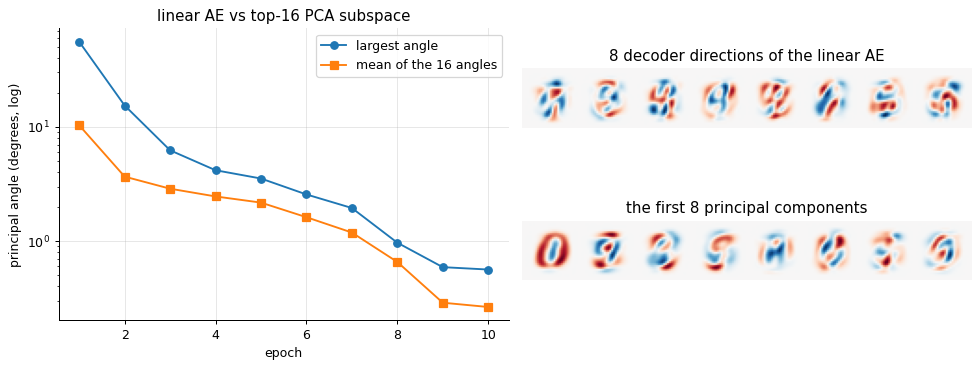

In [7]:
Wd = lin_dec.weight.detach()                              # D x k: the decoder's k directions in pixel space
gram = (Wd.T @ Wd).cpu().numpy()
cos_cols = (F.normalize(Wd, dim=0).T @ V_pc[:, :k_lin]).abs().max(1).values.cpu().numpy()
print(f"principal angles to the top-16 PCA subspace: largest {angle_hist[-1].max():.2f}°, mean {angle_hist[-1].mean():.2f}°  (0° = same subspace)")
print(f"loss above the PCA optimum: {excess_hist[-1]:.4f}, i.e. {excess_hist[-1] / pca_opt:.1e} of it")
print(f"W_d W_d^T is not the identity: diagonal from {gram.diagonal().min():.3f} to {gram.diagonal().max():.3f}, "
      f"largest off-diagonal |entry| {np.abs(gram - np.diag(gram.diagonal())).max():.3f}")
print(f"each decoder direction vs its closest single PC: |cos| between {cos_cols.min():.2f} and {cos_cols.max():.2f} (1 = identical)")
assert angle_hist[-1].max() < 2 and excess_hist[-1] / pca_opt < 1e-3

fig = plt.figure(figsize=(11, 4.2))
ax = fig.add_subplot(1, 2, 1)
ep_axis = np.arange(1, epochs + 1)
ax.semilogy(ep_axis, angle_hist.max(1), "o-", label="largest angle")
ax.semilogy(ep_axis, angle_hist.mean(1), "s-", label="mean of the 16 angles")
ax.set_xlabel("epoch"); ax.set_ylabel("principal angle (degrees, log)"); ax.legend()
ax.set_title("linear AE vs top-16 PCA subspace")
ax = fig.add_subplot(2, 2, 2)
d = Wd[:, :8].T.cpu().numpy()
ax.imshow(mosaic(0.5 + 0.5 * d / np.abs(d).max(1, keepdims=True), 8, fill=0.5), cmap="RdBu_r", vmin=0, vmax=1)
ax.axis("off"); ax.grid(False); ax.set_title("8 decoder directions of the linear AE")
ax = fig.add_subplot(2, 2, 4)
v = V_pc[:, :8].T.cpu().numpy()
ax.imshow(mosaic(0.5 + 0.5 * v / np.abs(v).max(1, keepdims=True), 8, fill=0.5), cmap="RdBu_r", vmin=0, vmax=1)
ax.axis("off"); ax.grid(False); ax.set_title("the first 8 principal components")
plt.tight_layout(); plt.show()

**What just happened?**
- After 10 epochs (7 seconds) the largest of the 16 principal angles between the decoder's subspace and the top-16 PCA subspace is 0.56° (mean 0.26°), and the loss is only 0.0004 above the PCA optimum 21.3976. Gradient descent on a linear autoencoder found the PCA subspace.
- The angle falls fast at first (55.8° after one epoch, 6.2° after three) and slowly at the end. Directions with nearly equal eigenvalues ($\lambda_{16} = 0.78$, $\lambda_{17} = 0.70$) are hard to tell apart, because exchanging them barely changes the loss.
- The subspace is right, the basis is not. $\mathbf{W}_d\mathbf{W}_d^\top$ has diagonal entries between 14.0 and 15.3 and off-diagonal entries up to 1.9, so the 16 decoder directions are neither unit nor orthogonal; each one matches its closest single principal component with $|\cos|$ between 0.39 and 0.64 only. The images on the right are mixtures of eigen-digits. Exercise 2 recovers the PCs from the trained network.

## 4. A non-linear autoencoder with a 2-D code

PCA can only fit a flat subspace. Digits lie near a curved, low-dimensional surface of $\mathbb{R}^{784}$ (the **manifold hypothesis**): making a "1" more slanted or a "0" wider does not move the pixels along a straight line. A non-linear encoder and decoder can follow the curve.

Architecture: an MLP 784 → 256 → 64 → $k$ with ReLU, and a mirror decoder $k$ → 64 → 256 → 784 with a sigmoid on the output (pixels lie in [0, 1]). Loss: MSE. Adam, mini-batches of 256. With $k = 2$ we can plot the code of every digit.

To compare codes with a number, we ask how well a 15-nearest-neighbour classifier predicts the label from the 2-D code (fit on 10,000 training codes, scored on the test codes). The labels never enter the training of the autoencoder: this measures how well it has organised the digits on its own. Embeddings like these are the input of the clustering methods of *Extra 2*.

trained in 13 s; 435,858 parameters
training MSE per epoch: [0.064 0.05  0.046 0.044 0.042 0.041 0.041 0.04  0.04  0.04  0.039 0.039]
test MSE per pixel with a 2-D code: AE 0.0392   PCA 0.0557
15-nearest-neighbour accuracy in the 2-D code (labels never used for the code): AE 0.738   PCA 0.450


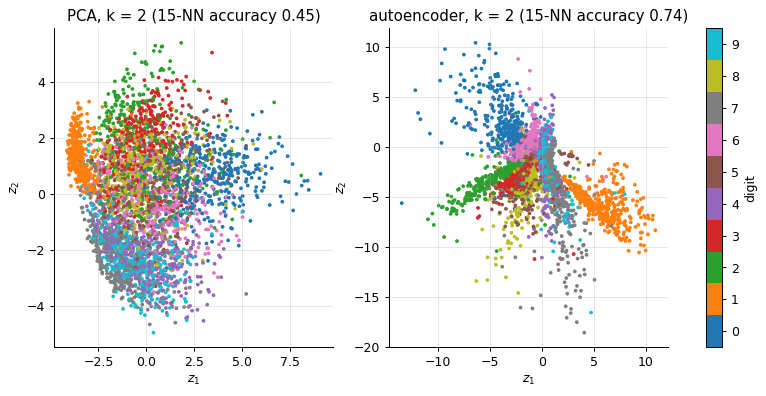

In [8]:
def mlp(sizes, last=None):
    """Linear layers with ReLU in between, and an optional final activation."""
    layers = []
    for a, b in zip(sizes[:-1], sizes[1:]):
        layers += [nn.Linear(a, b), nn.ReLU()]
    layers = layers[:-1]
    if last is not None:
        layers.append(last)
    return nn.Sequential(*layers)


class AE(nn.Module):
    """MLP autoencoder 784 -> 256 -> 64 -> k -> 64 -> 256 -> 784, sigmoid output (pixels in [0, 1])."""
    def __init__(self, k):
        super().__init__()
        self.enc = mlp([D, 256, 64, k])
        self.dec = mlp([k, 64, 256, D], nn.Sigmoid())

    def forward(self, x):
        return self.dec(self.enc(x))


def train(model, loss_fn, data, epochs, lr=2e-3, bs=256, seed=0):
    """Adam on shuffled mini-batches. data: a tensor or a tuple of tensors with the same number of rows.
    loss_fn(model, *batch) returns (loss, tuple of numbers to log). Returns the per-epoch means of the logged numbers."""
    data = data if isinstance(data, tuple) else (data,)
    N = len(data[0])
    g = torch.Generator().manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist = []
    model.train()
    for ep in range(epochs):
        perm = torch.randperm(N, generator=g).to(data[0].device)
        logs = []
        for i in range(0, N, bs):
            loss, parts = loss_fn(model, *[d[perm[i:i + bs]] for d in data])
            opt.zero_grad(); loss.backward(); opt.step()
            logs.append(parts)
        hist.append(np.mean(logs, 0))
    model.eval()
    return np.array(hist)


def mse_loss(model, xb):
    loss = F.mse_loss(model(xb), xb)                      # mean over pixels and images
    return loss, (loss.item(),)


def new_ae(k, seed=0):
    torch.manual_seed(seed)
    return AE(k).to(device)


t0 = time.time()
ae2 = new_ae(2)
hist_ae2 = train(ae2, mse_loss, X_train, epochs=12)
with torch.no_grad():
    Z_ae2 = ae2.enc(X_test)
    mse_ae2 = F.mse_loss(ae2(X_test), X_test).item()
print(f"trained in {time.time() - t0:.0f} s; {sum(p.numel() for p in ae2.parameters()):,} parameters")
print("training MSE per epoch:", hist_ae2[:, 0].round(4))
print(f"test MSE per pixel with a 2-D code: AE {mse_ae2:.4f}   PCA {mse_pca[2]:.4f}")

Z_pca2 = (X_test - mu_train) @ V_pc[:, :2]
with torch.no_grad():
    Ztr_ae2 = ae2.enc(X_train[:10000])
Ztr_pca2 = (X_train[:10000] - mu_train) @ V_pc[:, :2]


def knn_acc(Ztr, Zte):
    return KNeighborsClassifier(15).fit(Ztr.cpu().numpy(), y_train[:10000].cpu().numpy()).score(Zte.cpu().numpy(), y_test.cpu().numpy())


acc_ae2, acc_pca2 = knn_acc(Ztr_ae2, Z_ae2), knn_acc(Ztr_pca2, Z_pca2)
print(f"15-nearest-neighbour accuracy in the 2-D code (labels never used for the code): AE {acc_ae2:.3f}   PCA {acc_pca2:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
sel = slice(0, 4000)
for ax, Z, title in [(axes[0], Z_pca2, f"PCA, k = 2 (15-NN accuracy {acc_pca2:.2f})"), (axes[1], Z_ae2, f"autoencoder, k = 2 (15-NN accuracy {acc_ae2:.2f})")]:
    Zs = Z[sel].cpu().numpy()
    sc = ax.scatter(Zs[:, 0], Zs[:, 1], c=y_test[sel].cpu().numpy(), cmap="tab10", s=4, vmin=-0.5, vmax=9.5)
    ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$"); ax.set_title(title)
fig.colorbar(sc, ax=axes, ticks=range(10), label="digit")
plt.show()

**What just happened?**
- With the same 2 numbers per digit, the non-linear autoencoder reconstructs with a test MSE of 0.0392, against 0.0557 for PCA: 30% lower.
- The codes are far better organised. In the PCA plane most digits overlap, and a 15-nearest-neighbour classifier reaches 45.0%. In the autoencoder plane each digit has its own arm or cluster (73.8%), although no label was used. 0s, 1s and 2s are well separated; 4, 7 and 9, which share strokes, overlap.
- Look at the scale: the codes span tens of units (about −12 to 11 on $z_1$, −20 to 10 on $z_2$), in arms of different widths with empty space between them. Nothing in the loss asks for a particular scale or shape. Section 7 shows why this matters.

## 5. Latent size, overcomplete codes and sparsity

How small can the code be? We train the same autoencoder with $k = 4, 8, 16, 32$ (6 epochs each; $k = 2$ is the model of section 4, trained 12 epochs) and compare it with PCA at the same $k$: the same number of numbers per image. For each autoencoder we also find how many principal components PCA needs to reach the same test error.

4 more autoencoders trained in 24 s
 k   PCA test MSE   AE test MSE   AE / PCA   PCA needs k = ... to match the AE
 2   0.0557         0.0392        0.70       8
 4   0.0479         0.0301        0.63       13
 8   0.0374         0.0211        0.56       24
16   0.0269         0.0150        0.56       38
32   0.0168         0.0136        0.81       42


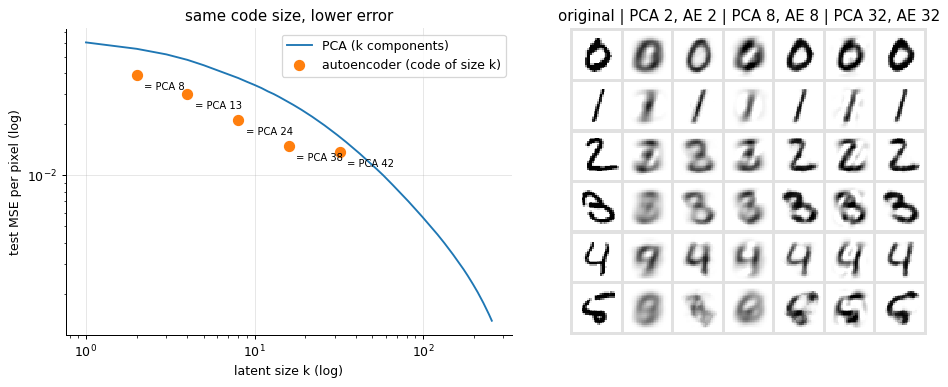

In [9]:
ks = [2, 4, 8, 16, 32]
aes = {2: ae2}
t0 = time.time()
for k in ks[1:]:
    aes[k] = new_ae(k)
    train(aes[k], mse_loss, X_train, epochs=6)
with torch.no_grad():
    mse_ae = {k: F.mse_loss(aes[k](X_test), X_test).item() for k in ks}
match = {k: int(np.argmax(pca_test_curve <= mse_ae[k])) + 1 for k in ks}   # PCA components needed to do as well
print(f"4 more autoencoders trained in {time.time() - t0:.0f} s")
print(" k   PCA test MSE   AE test MSE   AE / PCA   PCA needs k = ... to match the AE")
for k in ks:
    print(f"{k:2d}   {mse_pca[k]:.4f}         {mse_ae[k]:.4f}        {mse_ae[k] / mse_pca[k]:.2f}       {match[k]}")
assert all(mse_ae[k] < mse_pca[k] for k in ks)

fig = plt.figure(figsize=(11, 4.4))
ax = fig.add_subplot(1, 2, 1)
kk = np.arange(1, 257)
ax.loglog(kk, pca_test_curve[:256], label="PCA (k components)")
ax.loglog(ks, [mse_ae[k] for k in ks], "o", color="tab:orange", ms=8, label="autoencoder (code of size k)")
for k in ks:
    ax.annotate(f"= PCA {match[k]}", (k, mse_ae[k]), textcoords="offset points", xytext=(6, -12), fontsize=8)
ax.set_xlabel("latent size k (log)"); ax.set_ylabel("test MSE per pixel (log)"); ax.legend(); ax.set_title("same code size, lower error")
ax = fig.add_subplot(1, 2, 2)
tiles = []
for i in idx_show:
    with torch.no_grad():
        tiles += [X_test[i]] + sum([[pca_reconstruct(X_test[i:i + 1], k)[0].clamp(0, 1), aes[k](X_test[i:i + 1])[0]] for k in (2, 8, 32)], [])
show(ax, torch.stack(tiles), 7, "original | PCA 2, AE 2 | PCA 8, AE 8 | PCA 32, AE 32")
plt.tight_layout(); plt.show()

**Overcomplete codes.** With $k \ge D$ nothing forces compression: the network can learn the **identity**. It does not even need training. With $k = 2D$ and a ReLU,

$$
\mathbf{z} = \big(\mathrm{ReLU}(\mathbf{x}),\ \mathrm{ReLU}(-\mathbf{x})\big), \qquad \hat{\mathbf{x}} = \mathrm{ReLU}(\mathbf{x}) - \mathrm{ReLU}(-\mathbf{x}) = \mathbf{x}
$$

reconstructs every input exactly, digits or noise: zero loss, nothing learned. A large code therefore needs another constraint that rules out the identity:

- **sparsity**: penalise the code, with $\lambda\lVert\mathbf{z}\rVert_1$ (L1) or with $\sum_j \mathrm{KL}(\rho \,\Vert\, \hat\rho_j)$ between a small target activation rate $\rho$ and the mean activation $\hat\rho_j$ of unit $j$ (both read as Bernoulli probabilities). Each image may use only a few units, so the units become reusable parts: strokes, loops;
- **noise**: corrupt the input and ask for the clean image (denoising, section 6);
- a penalty on the derivatives of the encoder (contractive autoencoders).

Below: the hand-made identity, then two trained 784 → 1024 → 784 networks, a plain one and one with the L1 penalty $3 \cdot 10^{-4}\lVert\mathbf{z}\rVert_1$ added to the MSE (10,000 training digits, 3 epochs).

hand-made overcomplete AE (k = 1568): max |error| on test digits 0.0  on uniform noise 0.0 (expected 0, 0)


dense  784 -> 1024 -> 784: test MSE 0.0153, active units per digit 912 of 1024 (89.1%)
sparse 784 -> 1024 -> 784: test MSE 0.0231, active units per digit 49 of 1024 (4.8%)
for reference, the undercomplete MLP autoencoder with k = 32: test MSE 0.0136


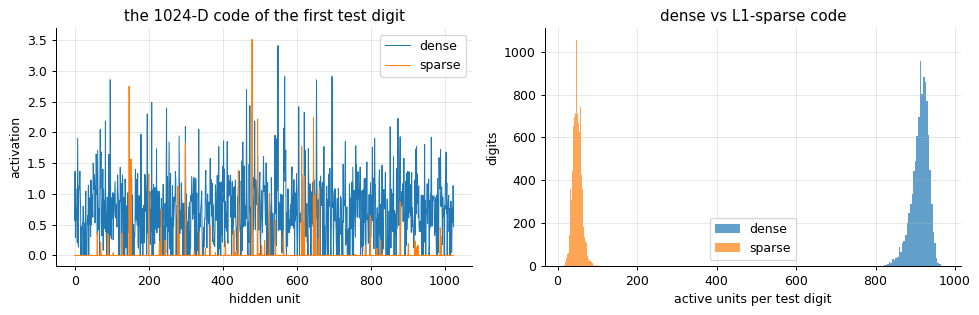

In [10]:
W_enc = torch.cat([torch.eye(D), -torch.eye(D)], 1).to(device)   # D x 2D: code = (relu(x), relu(-x)), 1568 numbers
W_dec = W_enc.T                                                   # 2D x D: x_hat = relu(x) - relu(-x)


def identity_ae(x):
    return F.relu(x @ W_enc) @ W_dec


noise = torch.rand(1000, D, generator=torch.Generator().manual_seed(0)).to(device)
print("hand-made overcomplete AE (k = 1568): max |error| on test digits",
      (identity_ae(X_test) - X_test).abs().max().item(), " on uniform noise", (identity_ae(noise) - noise).abs().max().item(), "(expected 0, 0)")
assert torch.equal(identity_ae(noise), noise)


class ShallowAE(nn.Module):
    """784 -> k (ReLU) -> 784 (sigmoid): one hidden layer, used with k = 1024 > 784."""
    def __init__(self, k):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(D, k), nn.ReLU())
        self.dec = nn.Sequential(nn.Linear(k, D), nn.Sigmoid())

    def forward(self, x):
        return self.dec(self.enc(x))


def sparse_loss(l1):
    def loss_fn(model, xb):
        h = model.enc(xb)
        rec = F.mse_loss(model.dec(h), xb)
        return rec + l1 * h.abs().sum(1).mean(), (rec.item(), (h > 0).float().mean().item())
    return loss_fn


over = {}
for name, l1 in [("dense", 0.0), ("sparse", 3e-4)]:
    torch.manual_seed(0)
    over[name] = ShallowAE(1024).to(device)
    train(over[name], sparse_loss(l1), X_train[:10000], epochs=3, lr=1e-3, bs=128)   # 10,000 digits are enough here
with torch.no_grad():
    H_over = {name: m.enc(X_test) for name, m in over.items()}
    for name, m in over.items():
        act = (H_over[name] > 0).float()
        print(f"{name:6s} 784 -> 1024 -> 784: test MSE {F.mse_loss(m(X_test), X_test):.4f}, "
              f"active units per digit {act.sum(1).mean():.0f} of 1024 ({act.mean():.1%})")
print(f"for reference, the undercomplete MLP autoencoder with k = 32: test MSE {mse_ae[32]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for name, c in [("dense", "tab:blue"), ("sparse", "tab:orange")]:
    axes[0].plot(H_over[name][0].cpu().numpy(), color=c, lw=0.8, label=name)
    axes[1].hist((H_over[name] > 0).sum(1).cpu().numpy(), bins=40, color=c, alpha=0.7, label=name)
axes[0].set_xlabel("hidden unit"); axes[0].set_ylabel("activation"); axes[0].set_title("the 1024-D code of the first test digit"); axes[0].legend()
axes[1].set_xlabel("active units per test digit"); axes[1].set_ylabel("digits"); axes[1].set_title("dense vs L1-sparse code"); axes[1].legend()
plt.tight_layout(); plt.show()

**Things to notice.**
- At every code size the autoencoder beats PCA, most clearly for small codes: with $k = 8$ its error (0.0211) equals that of PCA with 24 components, and with $k = 16$ (0.0150) that of PCA with 38. At $k = 32$ the gap narrows (0.0136 vs 0.0168): after 6 epochs the network is not converged, while PCA already keeps 74% of the variance.
- The hand-made identity reconstructs digits **and** uniform noise with error exactly 0. A training loss of zero says nothing about what has been learned.
- The trained overcomplete network has a low test error (0.0153), but 912 of its 1024 units (89%) fire for every digit: its code is a dense, larger copy of the input. With the L1 penalty only 49 units (4.8%) fire per digit, at a moderate cost in error (0.0231). Each unit then stands for a reusable part and each digit is described by a few of them: compression by sparsity instead of by size.

## 6. Convolutional and denoising autoencoders

**Convolutional encoder, transposed-convolution decoder.** For images, the encoder is a CNN: two convolutions with stride 2 take $28 \times 28$ to $14 \times 14$ to $7 \times 7$. The decoder has to go back up. Two options:

- **upsample, then convolve**: nearest-neighbour or bilinear upsampling, then an ordinary convolution;
- a **transposed convolution** (`nn.ConvTranspose2d`): every input pixel "paints" a copy of the kernel, scaled by its value, into the output, moving $s$ pixels at a time; overlapping copies add up. Output size: $(i - 1)s - 2p + k + \text{output\_padding}$. For $i = 7$, $s = 2$, $p = 1$, $k = 3$ and output padding 1: $12 - 2 + 3 + 1 = 14$.

Why "transposed": a convolution is a linear map, $\mathbf{y} = \mathbf{K}\mathbf{x}$ for a big sparse matrix $\mathbf{K}$, and the transposed convolution with the same weights computes $\mathbf{K}^\top\mathbf{y}$. It is what backpropagation computes for the gradient of a convolution. When the kernel size is not a multiple of the stride, some output pixels receive more kernel copies than others: the **checkerboard artefacts** of many generated images. Upsampling followed by a convolution avoids them.

In [11]:
x_small = torch.tensor([[1.0, 2.0], [3.0, 4.0]]).reshape(1, 1, 2, 2)
w_ones = torch.ones(1, 1, 3, 3)
y_up = F.conv_transpose2d(x_small, w_ones, stride=2)
print("input 2 x 2:\n", x_small[0, 0].numpy())
print("transposed convolution, 3 x 3 kernel of ones, stride 2 -> output (2 - 1)·2 + 3 = 5 x 5:\n", y_up[0, 0].numpy())
counts = F.conv_transpose2d(torch.ones(1, 1, 4, 4), w_ones, stride=2)[0, 0, 1:-1, 1:-1]
print("kernel copies that land on each output pixel (inside):\n", counts.numpy())
torch.manual_seed(0)
w_rand, u = torch.randn(1, 1, 3, 3), torch.randn(1, 1, 5, 5)
lhs = (F.conv2d(u, w_rand, stride=2) * x_small).sum()
rhs = (u * F.conv_transpose2d(x_small, w_rand, stride=2)).sum()
print(f"<conv(u), x> = {lhs:.4f}   <u, conv_transpose(x)> = {rhs:.4f}   (equal: the transposed convolution is the transpose)")
assert torch.isclose(lhs, rhs, atol=1e-5)

input 2 x 2:
 [[1. 2.]
 [3. 4.]]
transposed convolution, 3 x 3 kernel of ones, stride 2 -> output (2 - 1)·2 + 3 = 5 x 5:
 [[ 1.  1.  3.  2.  2.]
 [ 1.  1.  3.  2.  2.]
 [ 4.  4. 10.  6.  6.]
 [ 3.  3.  7.  4.  4.]
 [ 3.  3.  7.  4.  4.]]
kernel copies that land on each output pixel (inside):
 [[1. 2. 1. 2. 1. 2. 1.]
 [2. 4. 2. 4. 2. 4. 2.]
 [1. 2. 1. 2. 1. 2. 1.]
 [2. 4. 2. 4. 2. 4. 2.]
 [1. 2. 1. 2. 1. 2. 1.]
 [2. 4. 2. 4. 2. 4. 2.]
 [1. 2. 1. 2. 1. 2. 1.]]
<conv(u), x> = 5.0067   <u, conv_transpose(x)> = 5.0067   (equal: the transposed convolution is the transpose)


**Denoising autoencoder** (Vincent et al., 2008). Corrupt the input, keep the clean target:

$$
\tilde{\mathbf{x}} = \mathrm{clip}(\mathbf{x} + \sigma\boldsymbol{\varepsilon},\ 0,\ 1),\ \ \boldsymbol{\varepsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}), \qquad \text{minimise } \lVert g_\theta(f_\phi(\tilde{\mathbf{x}})) - \mathbf{x} \rVert^2 .
$$

The identity is now useless (it would return the noise), so even a large code has to learn what digits look like. With MSE the best possible output is $\mathbb{E}[\mathbf{x} \mid \tilde{\mathbf{x}}]$, the average clean image compatible with the noisy one. Other corruptions work too, for example hiding random pixels or patches: the idea behind BERT's masked tokens and masked image modelling.

We train two identical convolutional autoencoders (code size 32, 4 epochs each): a plain one on clean digits and a denoising one with $\sigma = 0.5$. Then we feed both the same noisy test digits.

two convolutional autoencoders (111,521 parameters each) trained in 22 s


clean test digits : plain AE MSE 0.0067, denoising AE MSE 0.0098


noisy test digits, MSE to the CLEAN digit: {'noisy input': 0.1156, 'plain AE(noisy)': 0.1107, 'denoising AE(noisy)': 0.0148}


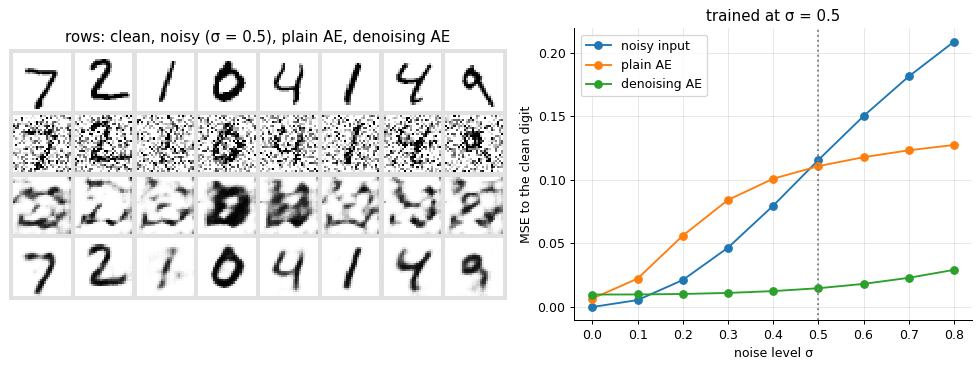

In [12]:
class ConvAE(nn.Module):
    """Conv encoder 1x28x28 -> 16x14x14 -> 32x7x7 -> k, mirrored by transposed convolutions."""
    def __init__(self, k=32):
        super().__init__()
        self.enc = nn.Sequential(nn.Unflatten(1, (1, 28, 28)),
                                 nn.Conv2d(1, 16, 3, stride=2, padding=1), nn.ReLU(),       # 16 x 14 x 14
                                 nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(),      # 32 x 7 x 7
                                 nn.Flatten(), nn.Linear(32 * 7 * 7, k))
        self.dec = nn.Sequential(nn.Linear(k, 32 * 7 * 7), nn.ReLU(), nn.Unflatten(1, (32, 7, 7)),
                                 nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),   # 16 x 14 x 14
                                 nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),               # 1 x 28 x 28
                                 nn.Flatten(), nn.Sigmoid())

    def forward(self, x):
        return self.dec(self.enc(x))


sigma_noise = 0.5


def add_noise(x, sigma=sigma_noise):
    return (x + sigma * torch.randn_like(x)).clamp(0, 1)


def denoise_loss(model, xb):
    loss = F.mse_loss(model(add_noise(xb)), xb)           # noisy input, CLEAN target
    return loss, (loss.item(),)


t0 = time.time()
torch.manual_seed(0); conv_ae = ConvAE().to(device)
train(conv_ae, mse_loss, X_train, epochs=4)
torch.manual_seed(0); conv_dae = ConvAE().to(device)
train(conv_dae, denoise_loss, X_train, epochs=4)
print(f"two convolutional autoencoders ({sum(p.numel() for p in conv_ae.parameters()):,} parameters each) trained in {time.time() - t0:.0f} s")
torch.manual_seed(1)
X_noisy = add_noise(X_test)
with torch.no_grad():
    print(f"clean test digits : plain AE MSE {F.mse_loss(conv_ae(X_test), X_test):.4f}, denoising AE MSE {F.mse_loss(conv_dae(X_test), X_test):.4f}")
    den = {"noisy input": F.mse_loss(X_noisy, X_test).item(), "plain AE(noisy)": F.mse_loss(conv_ae(X_noisy), X_test).item(),
           "denoising AE(noisy)": F.mse_loss(conv_dae(X_noisy), X_test).item()}
    print("noisy test digits, MSE to the CLEAN digit:", {k: round(v, 4) for k, v in den.items()})
    sigmas = np.linspace(0, 0.8, 9)
    curve = {"noisy input": [], "plain AE": [], "denoising AE": []}
    for s in sigmas:
        torch.manual_seed(2)
        Xn = add_noise(X_test, s)
        curve["noisy input"].append(F.mse_loss(Xn, X_test).item())
        curve["plain AE"].append(F.mse_loss(conv_ae(Xn), X_test).item())
        curve["denoising AE"].append(F.mse_loss(conv_dae(Xn), X_test).item())
assert den["denoising AE(noisy)"] < den["plain AE(noisy)"] < den["noisy input"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1.25, 1]})
with torch.no_grad():
    rows = torch.cat([X_test[:8], X_noisy[:8], conv_ae(X_noisy[:8]), conv_dae(X_noisy[:8])])
show(axes[0], rows, 8, "rows: clean, noisy (σ = 0.5), plain AE, denoising AE")
for name, ys in curve.items():
    axes[1].plot(sigmas, ys, "o-", label=name)
axes[1].axvline(sigma_noise, color="gray", ls=":")
axes[1].set_xlabel("noise level σ"); axes[1].set_ylabel("MSE to the clean digit"); axes[1].legend(); axes[1].set_title("trained at σ = 0.5")
plt.tight_layout(); plt.show()

**What just happened?**
- The transposed convolution reproduces the slides: each input value paints a $3 \times 3$ block, the centre receives all four copies ($1 + 2 + 3 + 4 = 10$), and the overlap counts form the 1–2–4 checkerboard pattern. The two inner products agree (5.0067): it is the transpose of the strided convolution.
- On clean digits the plain autoencoder is slightly better (MSE 0.0067 vs 0.0098). On noisy digits ($\sigma = 0.5$; the noisy input is at 0.1156 from the clean digit) the plain autoencoder barely helps (0.1107), while the denoising one gets down to 0.0148, close to its error on clean inputs.
- The plain autoencoder is not robust at all: for $\sigma$ between 0.1 and 0.4 its output is **worse** than the noisy input itself (0.0561 against 0.0212 at $\sigma = 0.2$). It never saw noise, so noisy digits fall outside what its encoder knows. The denoising autoencoder stays below 0.03 up to $\sigma = 0.8$, beyond the noise level it was trained on.

## 7. Why an autoencoder is not a generative model

A generative model lets us **sample** new images. A tempting shortcut: train an autoencoder, pick a random code, decode it. It works badly, for three reasons.

1. **No density.** Training only asks that each training code decodes to its image. Nothing says which codes are likely, so there is no distribution to sample from.
2. **Holes.** The codes form clusters with empty space between them. The decoder was never trained there, and it can output anything there.
3. **No scale.** The codes can sit anywhere, with any spread. A standard normal $\mathbf{z}$ can fall far from all of them.

To judge samples without looking at each one, we train an ordinary MNIST classifier and use it as a **referee**: on a real digit it is almost always confident, on a smudge it is not. We report its mean top probability and how often that probability exceeds 0.9. It is a rough proxy (a classifier can be confident on garbage), but here it agrees with the eye.

referee accuracy on the test set: 0.973
referee on real test digits:  mean confidence 0.966, confident (> 0.9) on 90.8%


2-D AE: 50% of the box (50 x 50 cells) contains no training code at all
referee on AE reconstructions of test digits: mean confidence 0.893, confident on 66.5%
referee on decoded random codes from the box:  mean confidence 0.942, confident on 83.2%
digit classes of the decoded random codes (%): [21, 16, 9, 10, 13, 1, 3, 9, 16, 2]
digit classes of the test set (%):             [10, 11, 10, 10, 10, 9, 10, 10, 10, 10]   -> total variation distance 0.25


16-D AE codes: per-dimension means from -12.2 to 4.5, std from 2.1 to 3.5
referee on decoded z ~ N(0, I):              mean confidence 0.461, confident on 2.0%
referee on decoded z ~ Gaussian fit to codes: mean confidence 0.770, confident on 37.1%


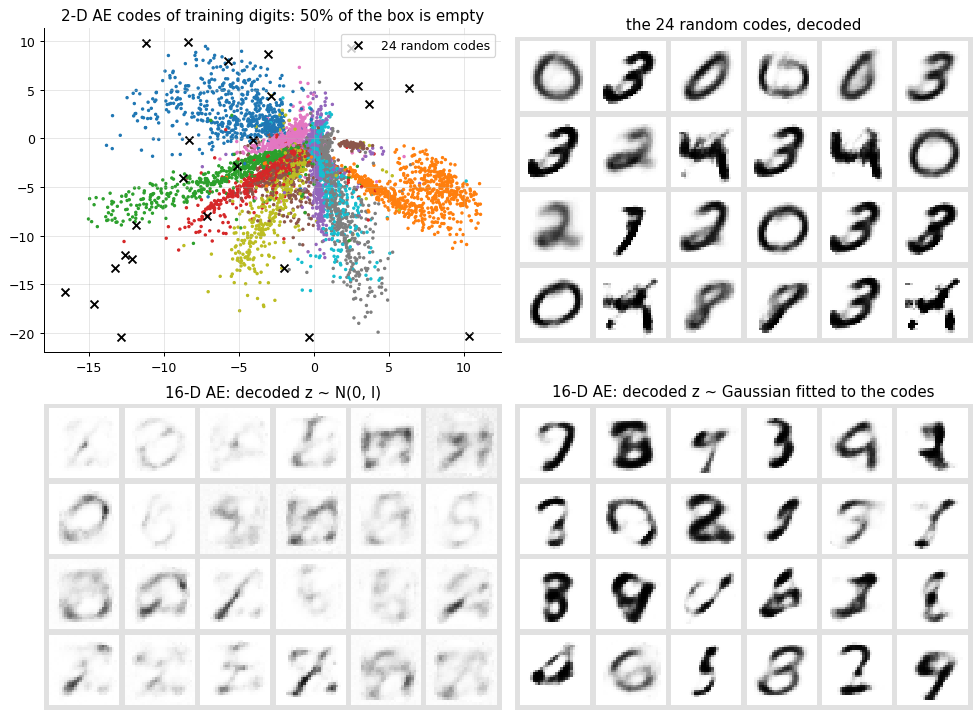

In [13]:
def ce_loss(model, xb, yb):
    loss = F.cross_entropy(model(xb), yb)
    return loss, (loss.item(),)


torch.manual_seed(0)
judge = mlp([D, 256, 10]).to(device)                      # an ordinary MNIST classifier, used as a referee
train(judge, ce_loss, (X_train, y_train), epochs=3)


@torch.no_grad()
def judge_conf(X):
    """Mean of the classifier's top probability, and the fraction of images it classifies with probability > 0.9."""
    p = F.softmax(judge(X), 1).max(1).values
    return p.mean().item(), (p > 0.9).float().mean().item()


with torch.no_grad():
    acc_judge = (judge(X_test).argmax(1) == y_test).float().mean().item()
print(f"referee accuracy on the test set: {acc_judge:.3f}")
print("referee on real test digits:  mean confidence %.3f, confident (> 0.9) on %.1f%%" % (judge_conf(X_test)[0], 100 * judge_conf(X_test)[1]))

with torch.no_grad():
    Z_tr2 = ae2.enc(X_train)
    lo, hi = Z_tr2.min(0).values, Z_tr2.max(0).values
    torch.manual_seed(0)
    z_box = lo + (hi - lo) * torch.rand(1000, 2, device=device)          # random codes in the box of the training codes
    x_box = ae2.dec(z_box)
    H2, _, _ = np.histogram2d(*Z_tr2.cpu().numpy().T, bins=50, range=[[lo[0].item(), hi[0].item()], [lo[1].item(), hi[1].item()]])
empty = (H2 == 0).mean()
print(f"2-D AE: {empty:.0%} of the box (50 x 50 cells) contains no training code at all")
with torch.no_grad():
    conf_rec2 = judge_conf(ae2(X_test))
conf_box2 = judge_conf(x_box)
with torch.no_grad():
    cls_box = torch.bincount(judge(x_box).argmax(1), minlength=10).float() / len(x_box)
cls_test = torch.bincount(y_test, minlength=10).float() / len(y_test)
tv_box = 0.5 * (cls_box - cls_test).abs().sum().item()        # total variation distance between the two class distributions
print("referee on AE reconstructions of test digits: mean confidence %.3f, confident on %.1f%%" % (conf_rec2[0], 100 * conf_rec2[1]))
print("referee on decoded random codes from the box:  mean confidence %.3f, confident on %.1f%%" % (conf_box2[0], 100 * conf_box2[1]))
print("digit classes of the decoded random codes (%):", (100 * cls_box).round().int().tolist())
print("digit classes of the test set (%):            ", (100 * cls_test).round().int().tolist(), f"  -> total variation distance {tv_box:.2f}")

ae16 = aes[16]
with torch.no_grad():
    Z16 = ae16.enc(X_train)
    m16, C16 = Z16.mean(0), torch.cov(Z16.T)
    torch.manual_seed(0)
    x_std = ae16.dec(torch.randn(1000, 16, device=device))
    x_fit = ae16.dec(torch.distributions.MultivariateNormal(m16, C16).sample((1000,)))
print(f"16-D AE codes: per-dimension means from {m16.min():.1f} to {m16.max():.1f}, std from {Z16.std(0).min():.1f} to {Z16.std(0).max():.1f}")
conf_std16, conf_fit16 = judge_conf(x_std), judge_conf(x_fit)
print("referee on decoded z ~ N(0, I):              mean confidence %.3f, confident on %.1f%%" % (conf_std16[0], 100 * conf_std16[1]))
print("referee on decoded z ~ Gaussian fit to codes: mean confidence %.3f, confident on %.1f%%" % (conf_fit16[0], 100 * conf_fit16[1]))

fig, axes = plt.subplots(2, 2, figsize=(11, 8.2))
Zs = Z_tr2[:6000].cpu().numpy()
axes[0, 0].scatter(Zs[:, 0], Zs[:, 1], c=y_train[:6000].cpu().numpy(), cmap="tab10", s=3, vmin=-0.5, vmax=9.5)
zb = z_box[:24].cpu().numpy()
axes[0, 0].scatter(zb[:, 0], zb[:, 1], marker="x", color="k", s=40, label="24 random codes")
axes[0, 0].legend(loc="upper right"); axes[0, 0].set_title(f"2-D AE codes of training digits: {empty:.0%} of the box is empty")
show(axes[0, 1], x_box[:24], 6, "the 24 random codes, decoded")
show(axes[1, 0], x_std[:24], 6, "16-D AE: decoded z ~ N(0, I)")
show(axes[1, 1], x_fit[:24], 6, "16-D AE: decoded z ~ Gaussian fitted to the codes")
plt.tight_layout(); plt.show()

**Interpolation.** Take two digits, walk along the straight line between their codes, and decode. If the codes filled a convex region, every point of the line would decode to a plausible digit. We compare with a plain cross-fade in pixel space, and we measure how far each point of the line is from the nearest training code, in units of the typical distance between a test code and its nearest training code (1 = as close as a real digit).

distance from the path to the nearest training code, in units of the typical code spacing: [1.2 1.1 1.3 1.4 1.6 1.3 1.1 1.  0.9 1. ]
referee confidence along the pixel cross-fade: [1.   1.   1.   0.99 0.91 0.5  0.92 0.98 0.99 1.  ]
referee confidence along the AE latent path:   [1.   1.   1.   0.96 0.52 0.98 1.   1.   1.   1.  ]


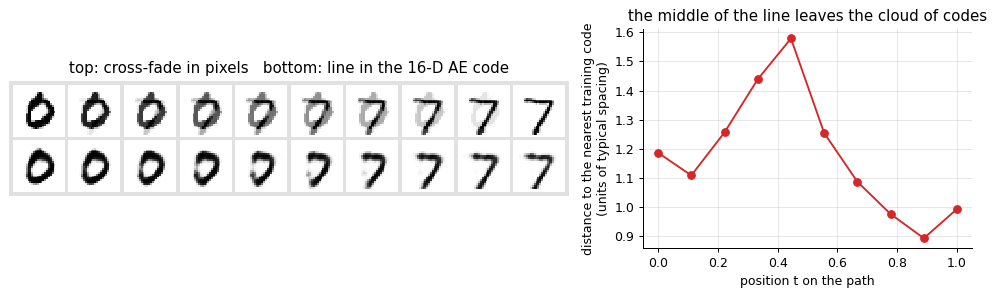

In [14]:
def nn_dist(A, B, chunk=500):
    """Distance from each row of A to its nearest row of B (in chunks, to keep the memory small)."""
    return torch.cat([torch.cdist(A[i:i + chunk], B).min(1).values for i in range(0, len(A), chunk)])


ia, ib = 3, 0                                              # a test 0 and a test 7
ts = torch.linspace(0, 1, 10, device=device)[:, None]
with torch.no_grad():
    za, zb_ = ae16.enc(X_test[[ia]]), ae16.enc(X_test[[ib]])
    path_pix = (1 - ts) * X_test[ia] + ts * X_test[ib]               # cross-fade in pixel space
    z_path = (1 - ts) * za + ts * zb_
    path_ae = ae16.dec(z_path)
    Z16_test = ae16.enc(X_test[:2000])
    typical = nn_dist(Z16_test, Z16).median()             # typical distance from a test code to its nearest training code
    off = (nn_dist(z_path, Z16) / typical).cpu().numpy()
    conf_pix = F.softmax(judge(path_pix), 1).max(1).values.cpu().numpy()
    conf_ae = F.softmax(judge(path_ae), 1).max(1).values.cpu().numpy()
print("distance from the path to the nearest training code, in units of the typical code spacing:", off.round(1))
print("referee confidence along the pixel cross-fade:", conf_pix.round(2))
print("referee confidence along the AE latent path:  ", conf_ae.round(2))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [1.7, 1]})
ax = axes[0]
show(ax, torch.cat([path_pix, path_ae]), 10, "top: cross-fade in pixels   bottom: line in the 16-D AE code")
ax = axes[1]
ax.plot(ts.cpu(), off, "o-", color="tab:red")
ax.set_xlabel("position t on the path"); ax.set_ylabel("distance to the nearest training code\n(units of typical spacing)")
ax.set_title("the middle of the line leaves the cloud of codes")
plt.tight_layout(); plt.show()

**What just happened?**
- **No density.** In 2-D the decoder makes digit-like images almost everywhere in the box: the referee is confident on 83.2% of them, more than on the autoencoder's own reconstructions (66.5%, often blends such as 4/9). But half of the box (50%) holds no training code, and the classes come out in the wrong proportions: 21% zeros, 16% ones and 16% eights, but 1% fives and 2% nines (total variation distance 0.25 from the test set). Without a density there is no right way to sample.
- **No scale.** The 16-D codes have per-dimension means between −12.2 and 4.5 and standard deviations between 2.1 and 3.5. A standard normal $\mathbf{z}$ falls far from all of them and decodes to smudges (mean confidence 0.461, confident on 2.0%). A Gaussian fitted to the codes after training is better (37.1%). Giving the codes a known density is exactly the VAE idea, but **during** training.
- **Interpolation.** The pixel cross-fade passes through half a 0 on top of half a 7 (referee confidence 0.50 in the middle). The line in the AE code stays near training codes (at most 1.6 times the typical distance) and mostly decodes to clean digits, but around $t = 0.44$ it produces an ambiguous image (confidence 0.52). Section 9 repeats the test with a VAE.

## 8. The variational autoencoder from scratch

**A latent-variable model.** Suppose every image is made in two steps: draw a code from a fixed **prior**, then draw the image from a distribution given by the decoder,

$$
\mathbf{z} \sim p(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I}), \qquad \mathbf{x} \sim p_\theta(\mathbf{x} \mid \mathbf{z}) = \prod_{j=1}^{D} \mathrm{Bernoulli}\big(x_j;\ \hat x_j\big), \quad \hat{\mathbf{x}} = \mathrm{sigmoid}(g_\theta(\mathbf{z})).
$$

Sampling new digits is then trivial. Maximum likelihood needs

$$
p_\theta(\mathbf{x}) = \int p_\theta(\mathbf{x} \mid \mathbf{z})\,p(\mathbf{z})\,d\mathbf{z},
$$

an integral over all codes, with no closed form when the decoder is a network. Estimating it with codes drawn from the prior fails too: for a given digit, almost every random $\mathbf{z}$ explains it terribly. The codes that matter are those of the **posterior** $p_\theta(\mathbf{z} \mid \mathbf{x}) = p_\theta(\mathbf{x} \mid \mathbf{z})p(\mathbf{z}) / p_\theta(\mathbf{x})$, which needs $p_\theta(\mathbf{x})$ again.

**The VAE idea** (Kingma & Welling, 2014; Rezende et al., 2014). Train an encoder that outputs a Gaussian approximation of the posterior,

$$
q_\phi(\mathbf{z} \mid \mathbf{x}) = \mathcal{N}\big(\boldsymbol{\mu}_\phi(\mathbf{x}),\ \operatorname{diag}\boldsymbol{\sigma}^2_\phi(\mathbf{x})\big),
$$

and maximise a lower bound on $\log p_\theta(\mathbf{x})$ that needs only samples from $q$.

**The KL divergence.** For two densities $q$ and $p$,

$$
\mathrm{KL}(q \,\Vert\, p) = \mathbb{E}_{\mathbf{z} \sim q}\Big[\log\frac{q(\mathbf{z})}{p(\mathbf{z})}\Big] = \int q(\mathbf{z})\log\frac{q(\mathbf{z})}{p(\mathbf{z})}\,d\mathbf{z} .
$$

It is $\ge 0$, with equality only when $q = p$. Proof (Jensen: $\log$ is concave, so $\mathbb{E}[\log Y] \le \log\mathbb{E}[Y]$): $-\mathrm{KL}(q \,\Vert\, p) = \mathbb{E}_q[\log(p/q)] \le \log\mathbb{E}_q[p/q] = \log\int p = 0$. It is **not symmetric**, $\mathrm{KL}(q \,\Vert\, p) \ne \mathrm{KL}(p \,\Vert\, q)$ in general, so it is not a distance. You have met it before: cross-entropy = entropy + KL, so training a classifier with cross-entropy minimises a KL.

**The ELBO, way 1: Jensen.** Multiply and divide by $q$ inside the integral, then use the concavity of the log:

$$
\log p_\theta(\mathbf{x}) = \log \mathbb{E}_{q_\phi(\mathbf{z} \mid \mathbf{x})}\Big[\frac{p_\theta(\mathbf{x} \mid \mathbf{z})\,p(\mathbf{z})}{q_\phi(\mathbf{z} \mid \mathbf{x})}\Big] \ \ge\ \mathbb{E}_{q_\phi(\mathbf{z} \mid \mathbf{x})}\Big[\log\frac{p_\theta(\mathbf{x} \mid \mathbf{z})\,p(\mathbf{z})}{q_\phi(\mathbf{z} \mid \mathbf{x})}\Big] =: \mathcal{L}(\mathbf{x}) .
$$

**Way 2: the exact gap.** For every $\mathbf{z}$, $p_\theta(\mathbf{x}) = p_\theta(\mathbf{x} \mid \mathbf{z})p(\mathbf{z}) / p_\theta(\mathbf{z} \mid \mathbf{x})$. Take the log, multiply and divide by $q$, and average over $\mathbf{z} \sim q$:

$$
\log p_\theta(\mathbf{x}) = \mathbb{E}_q\Big[\log\frac{p_\theta(\mathbf{x} \mid \mathbf{z})\,p(\mathbf{z})}{q_\phi(\mathbf{z} \mid \mathbf{x})}\Big] + \mathbb{E}_q\Big[\log\frac{q_\phi(\mathbf{z} \mid \mathbf{x})}{p_\theta(\mathbf{z} \mid \mathbf{x})}\Big] = \mathcal{L}(\mathbf{x}) + \mathrm{KL}\big(q_\phi(\mathbf{z} \mid \mathbf{x}) \,\Vert\, p_\theta(\mathbf{z} \mid \mathbf{x})\big).
$$

The gap is the KL from $q$ to the true posterior, so the bound is tight when the encoder is exact. Maximising $\mathcal{L}$ over $\phi$ improves the encoder; over $\theta$ it raises the likelihood (or tightens the bound).

**Two readable terms.** Split the log of the ratio as $\log p_\theta(\mathbf{x} \mid \mathbf{z}) - \log\big(q_\phi(\mathbf{z} \mid \mathbf{x}) / p(\mathbf{z})\big)$:

$$
\mathcal{L}(\mathbf{x}) = \underbrace{\mathbb{E}_{q_\phi(\mathbf{z} \mid \mathbf{x})}\big[\log p_\theta(\mathbf{x} \mid \mathbf{z})\big]}_{-\,\text{reconstruction error}} \ -\ \underbrace{\mathrm{KL}\big(q_\phi(\mathbf{z} \mid \mathbf{x}) \,\Vert\, p(\mathbf{z})\big)}_{\text{keeps the codes near the prior}} .
$$

The VAE loss is $-\mathcal{L}$: the autoencoder's reconstruction loss (here BCE, decoding a **random** code drawn around $\boldsymbol{\mu}_\phi(\mathbf{x})$) plus a penalty that pulls every $q_\phi(\mathbf{z} \mid \mathbf{x})$ towards $\mathcal{N}(\mathbf{0}, \mathbf{I})$.

**KL between Gaussians, in closed form.** For $q = \mathcal{N}(\mu, \sigma^2)$ and $p = \mathcal{N}(0, 1)$ in one dimension,

$$
\log q(z) - \log p(z) = -\log\sigma - \frac{(z - \mu)^2}{2\sigma^2} + \frac{z^2}{2} .
$$

Average over $z \sim q$, with $\mathbb{E}_q[(z - \mu)^2] = \sigma^2$ and $\mathbb{E}_q[z^2] = \mu^2 + \sigma^2$:

$$
\mathrm{KL}\big(\mathcal{N}(\mu, \sigma^2) \,\Vert\, \mathcal{N}(0, 1)\big) = -\log\sigma - \frac{1}{2} + \frac{\mu^2 + \sigma^2}{2} = \frac{1}{2}\big(\mu^2 + \sigma^2 - 1 - \log\sigma^2\big).
$$

It is 0 only at $\mu = 0$, $\sigma = 1$. The term $\mu^2$ pulls the code towards the origin; $\sigma^2 - 1 - \log\sigma^2 \ge 0$ punishes a posterior that is too narrow ($\sigma \to 0$ costs $-\log\sigma^2 \to \infty$) or too wide. With a diagonal covariance the coordinates are independent, the log-densities add, and so do the KLs:

$$
\mathrm{KL}\big(q_\phi(\mathbf{z} \mid \mathbf{x}) \,\Vert\, p(\mathbf{z})\big) = \frac{1}{2}\sum_{j=1}^{k}\big(\mu_j^2 + \sigma_j^2 - 1 - \log\sigma_j^2\big).
$$

Example (the slider of the slides): $\mu = 1$, $\sigma = 0.5$ gives $\frac{1}{2}(1 + 0.25 - 1 + 1.386) = 0.818$ nats. We check the formula against numerical integration.

mu =  0.0, sigma = 1.0:  closed form 0.000000   numerical integral 0.000000
mu =  1.0, sigma = 0.5:  closed form 0.818147   numerical integral 0.818147
mu =  2.0, sigma = 1.0:  closed form 2.000000   numerical integral 2.000000
mu =  0.0, sigma = 0.2:  closed form 1.129438   numerical integral 1.129438
mu = -1.0, sigma = 2.0:  closed form 1.306853   numerical integral 1.306853
asymmetry: KL(N(1, 0.5²) || N(0, 1)) = 0.818   but   KL(N(0, 1) || N(1, 0.5²)) = 2.807


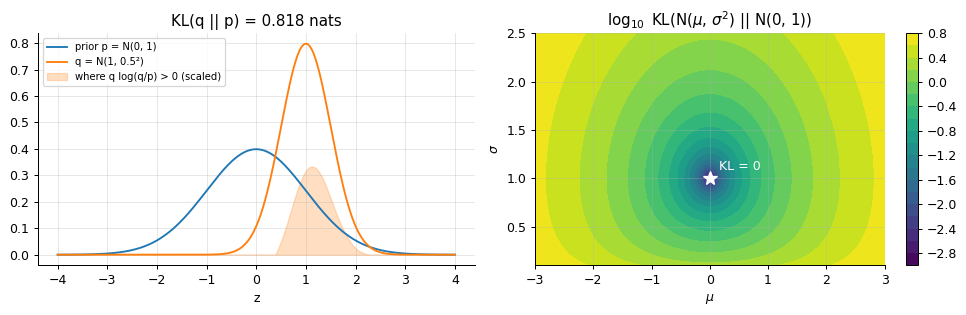

In [15]:
def kl_1d_closed(mu, s):
    """KL( N(mu, s²) || N(0, 1) ) in closed form."""
    return 0.5 * (mu**2 + s**2 - 1 - np.log(s**2))


def kl_numeric(mu_q, s_q, mu_p=0.0, s_p=1.0):
    """KL( N(mu_q, s_q²) || N(mu_p, s_p²) ) by numerical integration of q log(q/p)."""
    q, p = stats.norm(mu_q, s_q), stats.norm(mu_p, s_p)
    return integrate.quad(lambda z: q.pdf(z) * (q.logpdf(z) - p.logpdf(z)), mu_q - 15 * s_q, mu_q + 15 * s_q)[0]


for mu_, s_ in [(0, 1), (1, 0.5), (2, 1), (0, 0.2), (-1, 2)]:
    a, b = kl_1d_closed(mu_, s_), kl_numeric(mu_, s_)
    print(f"mu = {mu_:4.1f}, sigma = {s_:3.1f}:  closed form {a:.6f}   numerical integral {b:.6f}")
    assert abs(a - b) < 1e-6
print(f"asymmetry: KL(N(1, 0.5²) || N(0, 1)) = {kl_numeric(1, 0.5):.3f}   but   KL(N(0, 1) || N(1, 0.5²)) = {kl_numeric(0, 1, 1, 0.5):.3f}")

zz = np.linspace(-4, 4, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
q_, p_ = stats.norm(1, 0.5), stats.norm(0, 1)
axes[0].plot(zz, p_.pdf(zz), label="prior p = N(0, 1)")
axes[0].plot(zz, q_.pdf(zz), label="q = N(1, 0.5²)")
axes[0].fill_between(zz, 0, q_.pdf(zz) * np.clip(q_.logpdf(zz) - p_.logpdf(zz), 0, None) / 3, color="tab:orange", alpha=0.25,
                     label="where q log(q/p) > 0 (scaled)")
axes[0].set_xlabel("z"); axes[0].legend(fontsize=8); axes[0].set_title(f"KL(q || p) = {kl_1d_closed(1, 0.5):.3f} nats")
mus, sg = np.linspace(-3, 3, 121), np.linspace(0.1, 2.5, 121)
KLg = kl_1d_closed(mus[None, :], sg[:, None])
cs = axes[1].contourf(mus, sg, np.log10(KLg + 1e-3), levels=20, cmap="viridis")
axes[1].plot(0, 1, "w*", ms=12); axes[1].text(0.15, 1.08, "KL = 0", color="w")
axes[1].set_xlabel(r"$\mu$"); axes[1].set_ylabel(r"$\sigma$"); axes[1].set_title(r"$\log_{10}$ KL(N($\mu$, $\sigma^2$) || N(0, 1))")
fig.colorbar(cs, ax=axes[1])
plt.tight_layout(); plt.show()

**The reparameterisation trick.** The reconstruction term is an average over $\mathbf{z} \sim q_\phi$, and we need its gradient with respect to $\phi$. A random draw sits between $\phi$ and the loss, and backpropagation cannot go through "draw a sample". So write the sample as a deterministic function of $\phi$ and of noise that does not depend on $\phi$:

$$
\mathbf{z} = \boldsymbol{\mu}_\phi(\mathbf{x}) + \boldsymbol{\sigma}_\phi(\mathbf{x}) \odot \boldsymbol{\epsilon}, \qquad \boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}).
$$

Then $\mathbb{E}_{q_\phi}[h(\mathbf{z})] = \mathbb{E}_{\boldsymbol{\epsilon}}[h(\boldsymbol{\mu}_\phi + \boldsymbol{\sigma}_\phi \odot \boldsymbol{\epsilon})]$, the gradient moves inside the average, and backpropagation goes through $\boldsymbol{\mu}$ and $\boldsymbol{\sigma}$ as through any layer: $\boldsymbol{\epsilon}$ is just an extra input. One sample per image per step is enough in practice. The general alternative, the **score-function** (REINFORCE) estimator $\nabla_\phi\mathbb{E}_q[h] = \mathbb{E}_q[h(\mathbf{z})\,\nabla_\phi\log q_\phi(\mathbf{z})]$, works for any distribution, even discrete ones, but its variance is far larger (exercise 5).

**Practical details.**
- The encoder outputs $\log\sigma^2$, not $\sigma$: any real number is a valid output, and $\sigma = \exp(\frac{1}{2}\log\sigma^2) > 0$ always. A network that outputs $\sigma$ directly can return a negative or zero value, and the $\log\sigma^2$ of the KL becomes NaN.
- Pixels are **Bernoulli**, so the data should be black and white. We use **dynamic binarisation**: every time a training digit is used, each pixel is set to 1 with probability equal to its grey level. The test set is binarised once, with a fixed seed. Then $-\mathcal{L}$ is an honest upper bound on $-\log p_\theta(\mathbf{x})$ in nats per digit, and $-\mathcal{L}/(784 \ln 2)$ is in **bits per pixel**.
- Sum the reconstruction term over the 784 pixels and the KL over the $k$ latent dimensions, then average over the batch. Section 10 shows what happens otherwise.

First model: $k = 2$, the MLP sizes of the autoencoder, 15 epochs.

In [16]:
class VAE(nn.Module):
    """Encoder 784 -> 256 -> 64 -> (mu, log sigma²) of size k; decoder k -> 64 -> 256 -> 784 Bernoulli logits."""
    def __init__(self, k):
        super().__init__()
        self.k = k
        self.body = mlp([D, 256, 64])
        self.mu = nn.Linear(64, k)
        self.logvar = nn.Linear(64, k)                    # log sigma²: any real number is a valid output
        self.dec = mlp([k, 64, 256, D])                   # logits; sigmoid(logits) = Bernoulli means

    def encode(self, x):
        h = F.relu(self.body(x))
        return self.mu(h), self.logvar(h)

    def decode(self, z):
        return torch.sigmoid(self.dec(z))

    def forward(self, x):
        mu, logvar = self.encode(x)
        eps = torch.randn_like(mu)                        # the noise does not depend on the parameters
        z = mu + torch.exp(0.5 * logvar) * eps            # reparameterisation: z = mu + sigma * eps
        return self.dec(z), mu, logvar


def kl_gauss(mu, logvar):
    """KL( N(mu, diag exp(logvar)) || N(0, I) ), one value per row, in nats."""
    return 0.5 * (mu**2 + logvar.exp() - 1 - logvar).sum(1)


def elbo_terms(model, x):
    """Reconstruction term -log p(x|z) for one sample z ~ q(z|x), and KL(q(z|x) || p(z)), both per image."""
    logits, mu, logvar = model(x)
    rec = F.binary_cross_entropy_with_logits(logits, x, reduction="none").sum(1)
    return rec, kl_gauss(mu, logvar)


def vae_loss(beta=1.0):
    def loss_fn(model, xb):
        xb = torch.bernoulli(xb)                          # dynamic binarisation: a fresh black-and-white version every time
        rec, kl = elbo_terms(model, xb)
        return (rec + beta * kl).mean(), (rec.mean().item(), kl.mean().item())
    return loss_fn


torch.manual_seed(123)
X_test_bin = torch.bernoulli(X_test)                      # one fixed binarisation of the test set, for every evaluation
X_train_bin = torch.bernoulli(X_train[:10000])            # and of 10,000 training digits (for the nearest-neighbour test)
std_normal = torch.distributions.Normal(torch.tensor(0.0, device=device), torch.tensor(1.0, device=device))


@torch.no_grad()
def vae_eval(model, X=None):
    X = X_test_bin if X is None else X
    torch.manual_seed(0)
    rec, kl = elbo_terms(model, X)
    mu, logvar = model.encode(X)
    return {"rec": rec.mean().item(), "kl": kl.mean().item(), "elbo": -(rec + kl).mean().item(),
            "active": int((mu.var(0) > 0.01).sum()), "kl_dim": (0.5 * (mu**2 + logvar.exp() - 1 - logvar)).mean(0).cpu().numpy()}


t0 = time.time()
torch.manual_seed(0)
vae2 = VAE(2).to(device)
hist_vae2 = train(vae2, vae_loss(1.0), X_train, epochs=15)
ev2 = vae_eval(vae2)
print(f"2-D VAE trained in {time.time() - t0:.0f} s")
print("per epoch (train): reconstruction", hist_vae2[:, 0].round(1), "\n                   KL            ", hist_vae2[:, 1].round(2))
print(f"test: reconstruction {ev2['rec']:.1f} nats + KL {ev2['kl']:.2f} nats  ->  ELBO {ev2['elbo']:.1f} nats per digit "
      f"= {-ev2['elbo'] / (D * math.log(2)):.3f} bits per pixel")

2-D VAE trained in 20 s
per epoch (train): reconstruction [191.2 160.7 155.  151.2 148.8 146.8 145.3 143.9 142.9 141.7 140.9 140.3
 139.5 139.1 138.6] 
                   KL             [3.94 4.96 5.32 5.56 5.71 5.84 5.93 6.02 6.08 6.15 6.2  6.24 6.29 6.32
 6.34]
test: reconstruction 139.7 nats + KL 6.29 nats  ->  ELBO -146.0 nats per digit = 0.269 bits per pixel


In [17]:
# Monte Carlo check of the closed-form KL on 200 test digits: KL = E_q[log q(z|x) - log p(z)]
with torch.no_grad():
    mu, logvar = vae2.encode(X_test_bin[:200])
    q = torch.distributions.Normal(mu, torch.exp(0.5 * logvar))
    torch.manual_seed(0)
    zs = q.sample((20000,))                               # 20000 x 200 x 2
    kl_mc = (q.log_prob(zs) - std_normal.log_prob(zs)).sum(-1).mean(0)
    kl_cf = kl_gauss(mu, logvar)
print(f"KL on 200 test digits: closed form mean {kl_cf.mean():.4f}, Monte Carlo (20000 samples each) mean {kl_mc.mean():.4f};"
      f" largest relative difference on one digit {((kl_mc - kl_cf).abs() / kl_cf).max():.2%}")
assert ((kl_mc - kl_cf).abs() / kl_cf).max() < 0.03 and abs(kl_mc.mean() / kl_cf.mean() - 1) < 0.003

KL on 200 test digits: closed form mean 6.1841, Monte Carlo (20000 samples each) mean 6.1846; largest relative difference on one digit 0.35%


**How tight is the bound?** With $k = 2$ we can compute $\log p_\theta(\mathbf{x}) = \log\int p_\theta(\mathbf{x} \mid \mathbf{z})\,p(\mathbf{z})\,d\mathbf{z}$ by brute force: decode a fine grid of the plane ($181 \times 181$ points, step 0.05, from $-4.5$ to $4.5$) and add up. The same grid gives the true posterior $p_\theta(\mathbf{z} \mid \mathbf{x})$ and the gap $\mathrm{KL}(q_\phi \,\Vert\, p_\theta(\mathbf{z} \mid \mathbf{x}))$. As a cross-check we also estimate $\log p_\theta(\mathbf{x})$ by **importance sampling** with $q$ as the proposal, $\log\frac{1}{K}\sum_{i} p_\theta(\mathbf{x} \mid \mathbf{z}_i)\,p(\mathbf{z}_i) / q_\phi(\mathbf{z}_i \mid \mathbf{x})$ with $K = 5000$ samples: that is how $\log p(\mathbf{x})$ is reported when the code is too large for a grid.

test digit 3 (a 0): log p(x) = -136.23 (grid), -136.16 (importance sampling)   ELBO = −130.11 − 6.61 = -136.71   KL(q || posterior) = 0.47   ELBO + KL = -136.25
test digit 2 (a 1): log p(x) =  -40.14 (grid),  -40.20 (importance sampling)   ELBO = −34.32 − 7.02 =  -41.34   KL(q || posterior) = 1.18   ELBO + KL =  -40.17
test digit 8 (a 5): log p(x) = -279.07 (grid), -283.84 (importance sampling)   ELBO = −283.09 − 4.61 = -287.71   KL(q || posterior) = 8.58   ELBO + KL = -279.13
posterior mass within 3 standard deviations of q's mean: [0.918, 0.718, 0.005]
mean of q vs mode of the true posterior: [([-1.54, -1.0], [-1.5, -0.95]), ([1.99, -1.23], [2.1, -1.25]), ([0.24, 0.01], [0.25, 1.35])]
standard deviations of q(z|x) for the three digits: [[0.067, 0.04], [0.087, 0.059], [0.052, 0.073]]  (grid step 0.05)


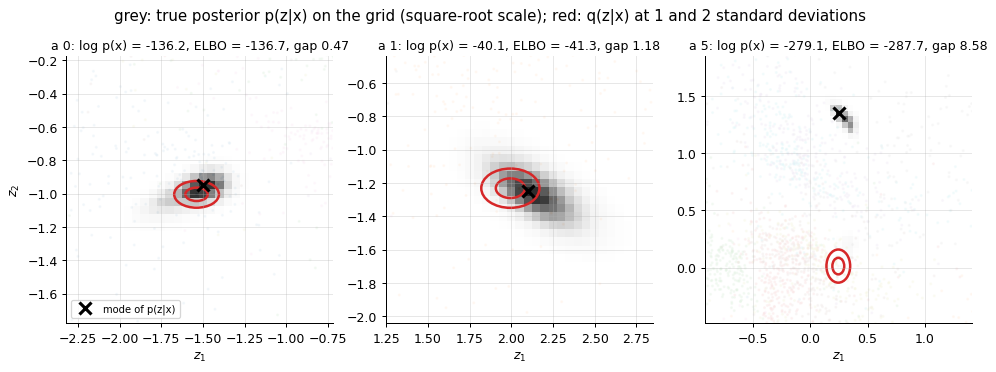

In [18]:
step = 0.05
g1 = torch.arange(-4.5, 4.5 + 1e-9, step, device=device)
ZZ = torch.cartesian_prod(g1, g1)                          # all grid points (z1, z2)
log_prior = -0.5 * (ZZ**2).sum(1) - math.log(2 * math.pi)
gap_rows = []
with torch.no_grad():
    logits_grid = vae2.dec(ZZ)                             # decode every grid point once
    for i in [3, 2, 8]:                                    # a test 0, a 1 and a 5
        x = X_test_bin[i]
        log_lik = -F.binary_cross_entropy_with_logits(logits_grid, x.expand_as(logits_grid), reduction="none").sum(1)
        log_joint = log_lik + log_prior                    # log p(x, z) on the grid
        log_px = (torch.logsumexp(log_joint, 0) + 2 * math.log(step)).item()      # log p(x) = log ∫ p(x|z) p(z) dz
        log_post = log_joint - log_px                      # log p(z|x) on the grid
        mu, logvar = vae2.encode(x[None])
        q = torch.distributions.Normal(mu[0], torch.exp(0.5 * logvar[0]))
        log_q = q.log_prob(ZZ).sum(1)
        w = torch.exp(log_q) * step**2                     # q's probability mass per cell
        kl_q_post = (w * (log_q - log_post)).sum().item()  # KL(q(z|x) || p(z|x)), the gap
        near = ((((ZZ - mu[0]) / torch.exp(0.5 * logvar[0])) ** 2).sum(1) <= 9).float()
        mass_near = (torch.exp(log_post) * step**2 * near).sum().item()   # posterior mass within 3 std of q's mean
        torch.manual_seed(0)
        zs = q.sample((5000,))
        ll = -F.binary_cross_entropy_with_logits(vae2.dec(zs), x.expand(5000, -1), reduction="none").sum(1)
        rec_term, kl_term = -ll.mean().item(), kl_gauss(mu, logvar).item()
        elbo = -rec_term - kl_term                         # Monte Carlo reconstruction term + closed-form KL
        log_w = ll + std_normal.log_prob(zs).sum(1) - q.log_prob(zs).sum(1)
        iwae = (torch.logsumexp(log_w, 0) - math.log(5000)).item()                  # importance-sampling estimate of log p(x)
        gap_rows.append(dict(i=i, log_px=log_px, elbo=elbo, rec=rec_term, kl=kl_term, gap=kl_q_post, iwae=iwae, near=mass_near, mode=ZZ[log_post.argmax()].cpu().numpy(), post=torch.exp(log_post).reshape(len(g1), len(g1)).cpu().numpy(),
                             mu=mu[0].cpu().numpy(), sd=torch.exp(0.5 * logvar[0]).cpu().numpy(), mass=w.sum().item()))
for r in gap_rows:
    print(f"test digit {r['i']} (a {y_test[r['i']].item()}): log p(x) = {r['log_px']:7.2f} (grid), {r['iwae']:7.2f} (importance sampling)   "
          f"ELBO = −{r['rec']:.2f} − {r['kl']:.2f} = {r['elbo']:7.2f}   KL(q || posterior) = {r['gap']:.2f}   ELBO + KL = {r['elbo'] + r['gap']:7.2f}")
    assert r["elbo"] < r["log_px"] and abs(r["elbo"] + r["gap"] - r["log_px"]) < 0.3    # log p(x) = ELBO + KL(q || posterior)
    assert r["elbo"] < r["iwae"] < r["log_px"] + 0.3                                    # importance sampling: between the two
print("posterior mass within 3 standard deviations of q's mean:", [round(r["near"], 3) for r in gap_rows])
print("mean of q vs mode of the true posterior:", [([round(float(v), 2) for v in r["mu"]], [round(float(v), 2) for v in r["mode"]]) for r in gap_rows])
print("standard deviations of q(z|x) for the three digits:", [[round(float(v), 3) for v in r["sd"]] for r in gap_rows], " (grid step 0.05)")

fig, axes = plt.subplots(1, 3, figsize=(11, 3.9))
with torch.no_grad():
    mu_all = vae2.encode(X_test_bin[:3000])[0].cpu().numpy()
G1 = g1.cpu().numpy()
for ax, r in zip(axes, gap_rows):
    ax.scatter(mu_all[:, 0], mu_all[:, 1], c=y_test[:3000].cpu().numpy(), cmap="tab10", s=2, alpha=0.25, vmin=-0.5, vmax=9.5)
    ax.pcolormesh(G1, G1, np.sqrt(r["post"].T / r["post"].max()), cmap="Greys", shading="nearest", alpha=0.85)
    for s in (1, 2):
        ax.add_patch(Ellipse(r["mu"], 2 * s * r["sd"][0], 2 * s * r["sd"][1], fill=False, color="tab:red", lw=2))
    ax.plot(*r["mode"], "kx", ms=10, mew=2.5, label="mode of p(z|x)")
    c = (r["mu"] + r["mode"]) / 2
    h = max(0.8, 0.5 * np.abs(r["mu"] - r["mode"]).max() + 0.5)
    ax.set_xlim(c[0] - h, c[0] + h); ax.set_ylim(c[1] - h, c[1] + h); ax.set_aspect("equal")
    ax.set_title(f"a {y_test[r['i']].item()}: log p(x) = {r['log_px']:.1f}, ELBO = {r['elbo']:.1f}, gap {r['gap']:.2f}", fontsize=10)
    ax.set_xlabel("$z_1$")
axes[0].set_ylabel("$z_2$"); axes[0].legend(loc="lower left", fontsize=8)
fig.suptitle("grey: true posterior p(z|x) on the grid (square-root scale); red: q(z|x) at 1 and 2 standard deviations", y=1.0)
plt.tight_layout(); plt.show()

**What just happened?**
- The closed-form KL agrees with numerical integration to $10^{-6}$, and on 200 test digits with a 20,000-sample Monte Carlo estimate within 0.35% (means 6.1841 and 6.1846). It is not symmetric: 0.818 nats one way, 2.807 the other.
- The 2-D VAE reaches a test ELBO of −146.0 nats per digit (reconstruction 139.7, KL 6.29), i.e. 0.269 bits per pixel. The KL grows during training, from 3.9 to 6.3 nats: the code carries more information as the decoder learns to use it.
- The grid confirms $\log p_\theta(\mathbf{x}) = \mathcal{L} + \mathrm{KL}(q \,\Vert\, p_\theta(\mathbf{z} \mid \mathbf{x}))$ to 0.06 nats. For the 0 and the 1 the gap is small (0.47 and 1.18 nats) and $q$ sits on the posterior: 92% and 72% of the posterior mass lie within 3 standard deviations of $q$'s mean. The posteriors are narrow (standard deviations 0.04 to 0.09), but a sum over a grid is very accurate for smooth bumps, and importance sampling agrees within 0.07 nats.
- For the 5 the gap is 8.58 nats. Its true posterior concentrates in a different region from $q$ (the cross marks its mode): only 0.5% of its mass lies within 3 standard deviations of $q$'s mean. The encoder has bet on one interpretation of an ambiguous digit, and a Gaussian cannot hedge between two places. Importance sampling with $q$ as the proposal inherits the problem: it never visits the right region and underestimates $\log p(\mathbf{x})$ by 4.8 nats (−283.84 against −279.07).

## 9. What the KL term does to the latent space

Summed over the data, the KL term $\frac{1}{2}\sum_j(\mu_j^2 + \sigma_j^2 - 1 - \log\sigma_j^2)$ pulls every code towards the origin and stops the posteriors from shrinking to points. The reconstruction term pushes the other way: codes of different digits must stay apart, or the decoder confuses them. The compromise is a code space where the posteriors overlap and cover the region where the prior has its mass, with no empty gaps. So a $\mathbf{z}$ drawn from $\mathcal{N}(\mathbf{0}, \mathbf{I})$ lands where the decoder was trained.

And since every code is decoded with noise around $\boldsymbol{\mu}_\phi(\mathbf{x})$, nearby codes must decode to similar images: the decoder becomes smooth. The 2-D VAE can be inspected directly: decode a regular grid of codes taken at prior quantiles ($z = \Phi^{-1}(u)$ for evenly spaced $u$, so that every cell has the same prior mass).

2-D VAE codes (means of q) of the test digits: mean [-0.11  0.04], std [1.16 1.06] (prior: 0 and 1)
2-D AE codes of the test digits:               mean [-0.77 -2.8 ], std [3.76 3.52]
referee on decoded prior samples of the 2-D VAE: mean confidence 0.867, confident on 60.4%   (2-D AE box: 0.942, 83.2%)
digit classes of the prior samples (%): [5, 11, 14, 8, 8, 5, 10, 7, 17, 15]   total variation to the test set 0.16 (2-D AE box: 0.25)
15-NN accuracy in the 2-D VAE code: 0.742   (AE 0.738, PCA 0.450)


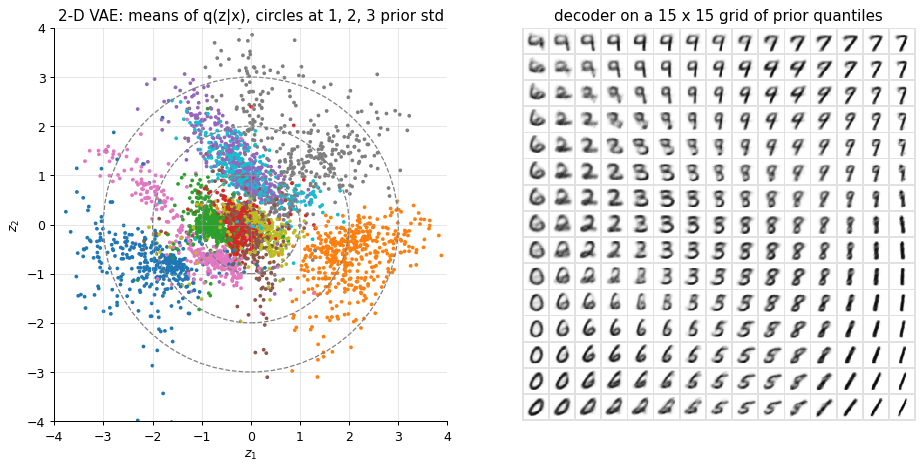

In [19]:
with torch.no_grad():
    Z_vae2 = vae2.encode(X_test_bin)[0]
print(f"2-D VAE codes (means of q) of the test digits: mean {Z_vae2.mean(0).cpu().numpy().round(2)}, std {Z_vae2.std(0).cpu().numpy().round(2)} (prior: 0 and 1)")
print(f"2-D AE codes of the test digits:               mean {Z_ae2.mean(0).cpu().numpy().round(2)}, std {Z_ae2.std(0).cpu().numpy().round(2)}")
with torch.no_grad():
    torch.manual_seed(0)
    x_prior2 = vae2.decode(torch.randn(1000, 2, device=device))
    pp = torch.tensor(stats.norm.ppf(np.linspace(0.04, 0.96, 15)), dtype=torch.float32, device=device)
    grid_z = torch.stack(torch.meshgrid(pp, pp.flip(0), indexing="xy"), -1).reshape(-1, 2)   # rows: z2 from high to low
    x_grid = vae2.decode(grid_z)
conf_prior2 = judge_conf(x_prior2)
with torch.no_grad():
    cls_prior2 = torch.bincount(judge(x_prior2).argmax(1), minlength=10).float() / len(x_prior2)
tv_prior2 = 0.5 * (cls_prior2 - cls_test).abs().sum().item()
with torch.no_grad():
    acc_vae2 = knn_acc(vae2.encode(X_train_bin)[0], Z_vae2)
print("referee on decoded prior samples of the 2-D VAE: mean confidence %.3f, confident on %.1f%%   (2-D AE box: %.3f, %.1f%%)"
      % (conf_prior2[0], 100 * conf_prior2[1], conf_box2[0], 100 * conf_box2[1]))
print("digit classes of the prior samples (%):", (100 * cls_prior2).round().int().tolist(), f"  total variation to the test set {tv_prior2:.2f} (2-D AE box: {tv_box:.2f})")
print(f"15-NN accuracy in the 2-D VAE code: {acc_vae2:.3f}   (AE {acc_ae2:.3f}, PCA {acc_pca2:.3f})")

fig = plt.figure(figsize=(11, 5.2))
ax = fig.add_subplot(1, 2, 1)
Zs = Z_vae2[:4000].cpu().numpy()
ax.scatter(Zs[:, 0], Zs[:, 1], c=y_test[:4000].cpu().numpy(), cmap="tab10", s=4, vmin=-0.5, vmax=9.5)
for r_ in (1, 2, 3):
    ax.add_patch(plt.Circle((0, 0), r_, fill=False, ls="--", color="gray"))
ax.set_aspect("equal"); ax.set_xlim(-4, 4); ax.set_ylim(-4, 4); ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")
ax.set_title("2-D VAE: means of q(z|x), circles at 1, 2, 3 prior std")
ax = fig.add_subplot(1, 2, 2)
show(ax, x_grid, 15, "decoder on a 15 x 15 grid of prior quantiles")
plt.tight_layout(); plt.show()

**A 16-D VAE: samples and interpolation.** Two dimensions are too few for good digits (compare the reconstruction errors of section 5). We train a VAE with $k = 16$ (10 epochs), sample from the prior, and repeat the interpolation of section 7. We also show what a true sample from $p_\theta(\mathbf{x} \mid \mathbf{z})$ looks like. The decoder outputs the **mean** of a Bernoulli for every pixel (the grey images we always show); drawing every pixel independently from it gives salt-and-pepper noise, because the model assumes the pixels are independent given $\mathbf{z}$.

16-D VAE trained in 14 s: test reconstruction 90.3 + KL 18.2 -> ELBO -108.5 nats = 0.200 bits per pixel; active dimensions 10 of 16


referee on decoded prior samples: 16-D VAE 0.797 (confident 45.0%)   vs 16-D AE with z ~ N(0, I) 0.461 (2.0%), Gaussian fit 0.770 (37.1%)
referee confidence along the interpolation: AE  [1.   1.   1.   0.96 0.52 0.98 1.   1.   1.   1.  ] 
                                            VAE [1.   1.   1.   0.89 0.94 0.99 1.   1.   1.   1.  ]
over 790 pairs of test digits: lowest referee confidence along the path, on average: pixels 0.539, AE 0.587, VAE 0.580; the VAE path is better on 48% of the pairs


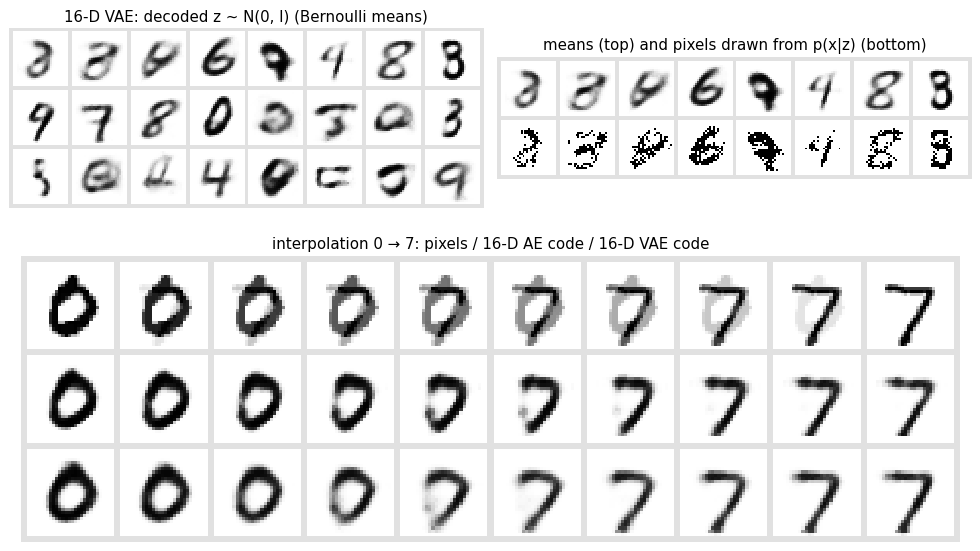

In [20]:
t0 = time.time()
torch.manual_seed(0)
vae16 = VAE(16).to(device)
hist_b1 = train(vae16, vae_loss(1.0), X_train, epochs=10)
ev16 = vae_eval(vae16)
print(f"16-D VAE trained in {time.time() - t0:.0f} s: test reconstruction {ev16['rec']:.1f} + KL {ev16['kl']:.1f} -> ELBO {ev16['elbo']:.1f} nats "
      f"= {-ev16['elbo'] / (D * math.log(2)):.3f} bits per pixel; active dimensions {ev16['active']} of 16")
with torch.no_grad():
    torch.manual_seed(0)
    x_prior16 = vae16.decode(torch.randn(1000, 16, device=device))
    mu_a, mu_b = vae16.encode(X_test[[ia]])[0], vae16.encode(X_test[[ib]])[0]
    path_vae = vae16.decode((1 - ts) * mu_a + ts * mu_b)
    conf_vae_path = F.softmax(judge(path_vae), 1).max(1).values.cpu().numpy()
    torch.manual_seed(1)
    x_sampled_pixels = torch.bernoulli(x_prior16[:8])      # a real sample from p(x|z): every pixel drawn
conf_prior16 = judge_conf(x_prior16)

# the same test on many pairs: the first 5 test digits of every class, pairs of different classes,
# kept when both models reconstruct both end points as the right digit with confidence > 0.95
cand = torch.cat([torch.nonzero(y_test == d)[:5, 0] for d in range(10)])
with torch.no_grad():
    Za, Zv = ae16.enc(X_test[cand]), vae16.encode(X_test[cand])[0]
    mins = {"pixels": [], "AE": [], "VAE": []}
    for a in range(len(cand)):
        for b in range(len(cand)):
            ya, yb = y_test[cand[a]].item(), y_test[cand[b]].item()
            if ya >= yb:
                continue
            paths = {"pixels": (1 - ts) * X_test[cand[a]] + ts * X_test[cand[b]],
                     "AE": ae16.dec((1 - ts) * Za[a] + ts * Za[b]), "VAE": vae16.decode((1 - ts) * Zv[a] + ts * Zv[b])}
            probs = {k: F.softmax(judge(v), 1) for k, v in paths.items()}
            ends = all(probs[k][0].argmax() == ya and probs[k][-1].argmax() == yb and probs[k][[0, -1]].max(1).values.min() > 0.95 for k in ("AE", "VAE"))
            if ends:
                for k in mins:
                    mins[k].append(probs[k].max(1).values.min().item())
interp_agg = {k: float(np.mean(v)) for k, v in mins.items()}
interp_agg["n"] = len(mins["AE"])
interp_agg["vae_better"] = float(np.mean(np.array(mins["VAE"]) > np.array(mins["AE"])))
print("referee on decoded prior samples: 16-D VAE %.3f (confident %.1f%%)   vs 16-D AE with z ~ N(0, I) %.3f (%.1f%%), Gaussian fit %.3f (%.1f%%)"
      % (conf_prior16[0], 100 * conf_prior16[1], conf_std16[0], 100 * conf_std16[1], conf_fit16[0], 100 * conf_fit16[1]))
print("referee confidence along the interpolation: AE ", conf_ae.round(2), "\n                                            VAE", conf_vae_path.round(2))
print(f"over {interp_agg['n']} pairs of test digits: lowest referee confidence along the path, on average: pixels {interp_agg['pixels']:.3f}, "
      f"AE {interp_agg['AE']:.3f}, VAE {interp_agg['VAE']:.3f}; the VAE path is better on {interp_agg['vae_better']:.0%} of the pairs")

fig = plt.figure(figsize=(11, 6.6))
ax = fig.add_subplot(2, 2, 1)
show(ax, x_prior16[:24], 8, "16-D VAE: decoded z ~ N(0, I) (Bernoulli means)")
ax = fig.add_subplot(2, 2, 2)
show(ax, torch.cat([x_prior16[:8], x_sampled_pixels]), 8, "means (top) and pixels drawn from p(x|z) (bottom)")
ax = fig.add_subplot(2, 1, 2)
show(ax, torch.cat([path_pix, path_ae, path_vae]), 10, "interpolation 0 → 7: pixels / 16-D AE code / 16-D VAE code")
plt.tight_layout(); plt.show()

**What just happened?**
- The KL term did its job. The 2-D VAE codes have mean (−0.11, 0.04) and standard deviation (1.16, 1.06), close to the prior's 0 and 1, while the AE codes sit at (−0.77, −2.80) with spreads of 3.76 and 3.52. The VAE codes fill a disc without large gaps and separate the digits as well as the AE codes (15-NN accuracy 74.2% vs 73.8%).
- The grid decode is a continuous map of digits with smooth morphs between neighbours: 0s and 6s on the left, 9s and 7s along the top, 1s on the right, 2s, 3s, 5s and 8s in the middle. Prior samples come out in better proportions than the AE's box samples (total variation 0.16 vs 0.25), but two dimensions are too few for sharp digits: the referee is confident on 60.4% of them.
- In 16-D the VAE prior samples are far better than the AE's with $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ (confident on 45.0% vs 2.0%) and better than a Gaussian fitted to the AE codes after training (37.1%). Test ELBO −108.5 nats = 0.200 bits per pixel, with 10 of the 16 dimensions active.
- Interpolation: in this example the VAE morphs the 0 into a 7 without an ambiguous step (lowest referee confidence 0.89, against 0.52 for the AE and 0.50 for pixels). Over 790 pairs of test digits, though, the average lowest confidence is 0.54 (pixels), 0.59 (AE) and 0.58 (VAE), and the VAE path is better on only 48% of the pairs. The VAE's decisive advantage is sampling from the prior; smooth interpolations are frequent, not guaranteed.
- The decoder outputs are **means**. Drawing every pixel from them gives speckled digits, because the model treats the pixels as independent given $\mathbf{z}$.

## 10. β-VAE, rate and distortion, posterior collapse

Weight the KL term (Higgins et al., 2017):

$$
\text{loss} = \underbrace{\mathbb{E}_{q_\phi}\big[-\log p_\theta(\mathbf{x} \mid \mathbf{z})\big]}_{\text{distortion } D} + \beta\,\underbrace{\mathrm{KL}\big(q_\phi(\mathbf{z} \mid \mathbf{x}) \,\Vert\, p(\mathbf{z})\big)}_{\text{rate } R} .
$$

The names come from compression. The **rate** $R$ is how many nats the code carries about the image (averaged over the data it is an upper bound on the mutual information between $\mathbf{x}$ and $\mathbf{z}$); the **distortion** $D$ is the reconstruction error. $\beta = 1$ is the ELBO, $-\mathcal{L} = D + R$. With $\beta < 1$ the code may carry more nats: sharper reconstructions, codes that spread out like a plain autoencoder's. With $\beta > 1$ it must carry fewer: smoother codes (often more **disentangled**, one factor per dimension), blurrier images. Every $\beta$ picks one point of the trade-off; only $\beta = 1$ maximises the bound on the likelihood.

A dimension that carries nothing has $q_\phi(z_j \mid \mathbf{x}) = p(z_j)$ for every $\mathbf{x}$: its KL is 0 and the decoder ignores it. We count the **active dimensions**, those whose mean moves with the input: $\mathrm{Var}_{\mathbf{x}}\big[\mu_j(\mathbf{x})\big] > 0.01$ (Burda et al., 2016).

We train $\beta = 0.1$ and $\beta = 4$ with $k = 16$ (10 epochs each) and compare with the $\beta = 1$ model of section 9.

In [21]:
betas = [0.1, 1.0, 4.0]
vaes, hists, evs = {1.0: vae16}, {1.0: hist_b1}, {1.0: ev16}
t0 = time.time()
for b in [0.1, 4.0]:
    torch.manual_seed(0)
    vaes[b] = VAE(16).to(device)
    hists[b] = train(vaes[b], vae_loss(b), X_train, epochs=10)
    evs[b] = vae_eval(vaes[b])
print(f"two more 16-D VAEs trained in {time.time() - t0:.0f} s")
samples_beta, conf_beta = {}, {}
with torch.no_grad():
    for b in betas:
        torch.manual_seed(0)
        samples_beta[b] = vaes[b].decode(torch.randn(1000, 16, device=device))
        conf_beta[b] = judge_conf(samples_beta[b])
print(" beta   distortion (rec)   rate (KL)   ELBO (beta = 1)   active dims   referee on samples")
for b in betas:
    e = evs[b]
    print(f"{b:5.1f}   {e['rec']:8.1f}          {e['kl']:6.1f}      {e['elbo']:8.1f}         {e['active']:3d}          {conf_beta[b][0]:.3f} ({100 * conf_beta[b][1]:.0f}% confident)")
assert evs[0.1]["rec"] < evs[1.0]["rec"] < evs[4.0]["rec"] and evs[0.1]["kl"] > evs[1.0]["kl"] > evs[4.0]["kl"]
assert evs[1.0]["elbo"] > max(evs[0.1]["elbo"], evs[4.0]["elbo"])

two more 16-D VAEs trained in 27 s
 beta   distortion (rec)   rate (KL)   ELBO (beta = 1)   active dims   referee on samples
  0.1       73.0            48.6        -121.6          16          0.623 (17% confident)
  1.0       90.3            18.2        -108.5          10          0.797 (45% confident)
  4.0      119.3             7.4        -126.7           6          0.847 (56% confident)


**Posterior collapse, and the bug that causes it.** If the KL term is too strong, the cheapest solution is $q_\phi(\mathbf{z} \mid \mathbf{x}) = p(\mathbf{z})$ for every input: KL = 0, the code carries nothing, and the decoder outputs one average image. This is **posterior collapse**. It also happens with a strong decoder (an autoregressive one, which can model the pixels without the code), and the classic remedies are a KL warm-up (start with $\beta = 0$ and raise it to 1 over the first epochs) or a minimum rate per dimension ("free bits").

The most common way to get it by accident is a bookkeeping error. `F.binary_cross_entropy(x_hat, x)` uses `reduction="mean"`: it divides the reconstruction by the 784 pixels. If the KL is summed over the latent dimensions as usual, the loss is $\frac{1}{784}(D + 784\,R)$, a β-VAE with $\beta = 784$. We train it for 4 epochs.

trained in 6 s. With the bug: reconstruction 206.2 nats, KL 0.000 nats, active dimensions 0 of 16  (equivalent to beta = 784)
the 8 reconstructions differ by 0.0000 per pixel on average: the decoder outputs (almost) one image for every input


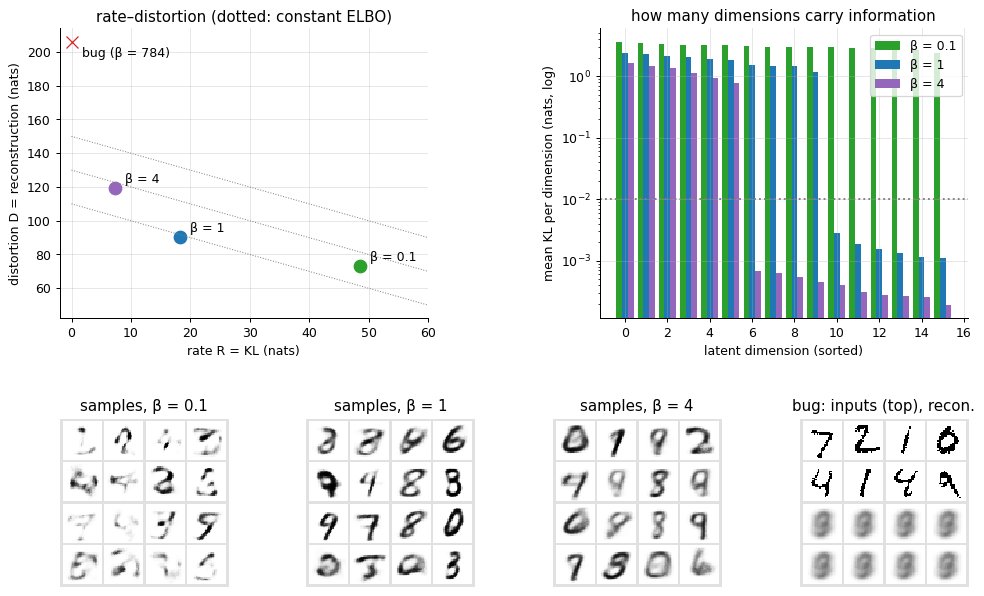

In [22]:
def buggy_loss(model, xb):
    """The classic mistake: reconstruction averaged over the 784 pixels, KL summed over the latent dimensions."""
    xb = torch.bernoulli(xb)
    logits, mu, logvar = model(xb)
    rec = F.binary_cross_entropy_with_logits(logits, xb)          # reduction="mean": divides by 784 (and by the batch)
    kl = kl_gauss(mu, logvar).mean()
    return rec + kl, (rec.item() * D, kl.item())


t0 = time.time()
torch.manual_seed(0)
vae_bug = VAE(16).to(device)
hist_bug = train(vae_bug, buggy_loss, X_train, epochs=4)
ev_bug = vae_eval(vae_bug)
print(f"trained in {time.time() - t0:.0f} s. With the bug: reconstruction {ev_bug['rec']:.1f} nats, KL {ev_bug['kl']:.3f} nats, "
      f"active dimensions {ev_bug['active']} of 16  (equivalent to beta = {D})")
with torch.no_grad():
    rec_bug = vae_bug.decode(vae_bug.encode(X_test[:8])[0])
    spread = rec_bug.std(0).mean().item()
print(f"the 8 reconstructions differ by {spread:.4f} per pixel on average: the decoder outputs (almost) one image for every input")
assert ev_bug["kl"] < 0.5 and ev_bug["active"] <= 1

fig = plt.figure(figsize=(11, 7.4))
ax = fig.add_subplot(2, 2, 1)
for b, c in zip(betas, ["tab:green", "tab:blue", "tab:purple"]):
    ax.plot(evs[b]["kl"], evs[b]["rec"], "o", color=c, ms=10)
    ax.annotate(f"β = {b:g}", (evs[b]["kl"], evs[b]["rec"]), textcoords="offset points", xytext=(8, 4))
ax.plot(ev_bug["kl"], ev_bug["rec"], "x", color="tab:red", ms=10); ax.annotate("bug (β = 784)", (ev_bug["kl"], ev_bug["rec"]), textcoords="offset points", xytext=(8, -12))
kl_line = np.linspace(0, 60, 100)
for elbo_level in (-110, -130, -150):
    ax.plot(kl_line, -elbo_level - kl_line, color="gray", lw=0.8, ls=":")
ax.set_xlabel("rate R = KL (nats)"); ax.set_ylabel("distortion D = reconstruction (nats)"); ax.set_xlim(-2, 60)
ax.set_title("rate–distortion (dotted: constant ELBO)")
ax = fig.add_subplot(2, 2, 2)
w_ = 0.27
for j, (b, c) in enumerate(zip(betas, ["tab:green", "tab:blue", "tab:purple"])):
    ax.bar(np.arange(16) + (j - 1) * w_, np.sort(evs[b]["kl_dim"])[::-1], w_, color=c, label=f"β = {b:g}")
ax.axhline(0.01, color="gray", ls=":")
ax.set_yscale("log"); ax.set_xlabel("latent dimension (sorted)"); ax.set_ylabel("mean KL per dimension (nats, log)"); ax.legend()
ax.set_title("how many dimensions carry information")
for j, b in enumerate(betas):
    ax = fig.add_subplot(2, 4, 5 + j)
    show(ax, samples_beta[b][:16], 4, f"samples, β = {b:g}")
ax = fig.add_subplot(2, 4, 8)
show(ax, torch.cat([X_test_bin[:8], rec_bug]), 4, "bug: inputs (top), recon.")
plt.tight_layout(); plt.show()

**What just happened?**
- The sweep traces the rate–distortion trade-off. β = 0.1: distortion 73.0 nats, rate 48.6, all 16 dimensions active. β = 1: 90.3 and 18.2, 10 active. β = 4: 119.3 and 7.4, 6 active. As it must, β = 1 has the best ELBO (−108.5, against −121.6 and −126.7): it is the only one that optimises the bound itself.
- Sample quality does not follow the ELBO. β = 0.1 has the sharpest reconstructions but the worst samples (17% confident): its codes spread out like an autoencoder's and no longer match the prior. β = 4 gives the most typical samples (56%), but blurred, and its reconstructions lose details.
- The per-dimension KL shows how the code is used: a dimension is either informative (around 1 to 3 nats) or switched off (below 0.01 nats, $q(z_j \mid \mathbf{x}) = p(z_j)$). A larger β switches more of them off.
- The averaging bug is β = 784. After 4 epochs the KL is 0.000 nats, no dimension is active, and the decoder returns the same image for every input (spread 0.0000 per pixel) at a cost of 206.2 nats: posterior collapse. The model trains without any error message and its loss goes down; only logging the KL term reveals the problem.

## 11. A conditional VAE

To generate a chosen digit, condition both networks on the label $y$ (Sohn et al., 2015):

$$
q_\phi(\mathbf{z} \mid \mathbf{x}, y), \qquad p_\theta(\mathbf{x} \mid \mathbf{z}, y), \qquad \mathcal{L}(\mathbf{x}, y) = \mathbb{E}_{q_\phi}\big[\log p_\theta(\mathbf{x} \mid \mathbf{z}, y)\big] - \mathrm{KL}\big(q_\phi(\mathbf{z} \mid \mathbf{x}, y) \,\Vert\, p(\mathbf{z})\big).
$$

In code: append the one-hot label to the encoder input and to the decoder input. The label already says which digit it is, so the code does not need to: it is free to describe the **style** (slant, width, thickness). To draw a 7, sample $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ and decode it with $y = 7$. The same $\mathbf{z}$ with different labels gives the same style for every digit. We use $k = 2$ (10 epochs) so that the style space is a plane.

CVAE trained in 14 s: test reconstruction 127.9 + KL 4.64 -> ELBO -132.6 nats   (2-D VAE without labels: -146.0)
the referee recognises the requested digit in 99.8% of 1000 generated images


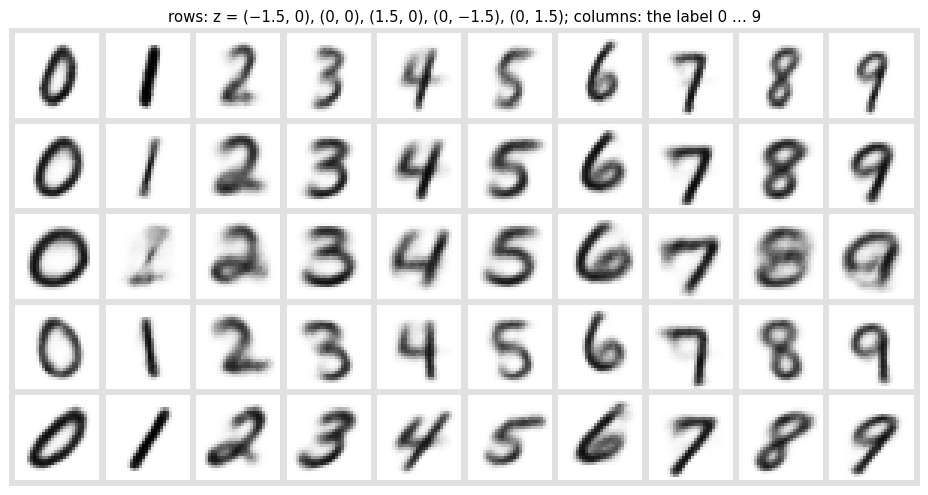

In [23]:
class CVAE(VAE):
    """Conditional VAE: the one-hot label is appended to the encoder input and to the decoder input."""
    def __init__(self, k, n_classes=10):
        super().__init__(k)
        self.body = mlp([D + n_classes, 256, 64])
        self.dec = mlp([k + n_classes, 64, 256, D])

    def forward(self, x, y1h):
        h = F.relu(self.body(torch.cat([x, y1h], 1)))
        mu, logvar = self.mu(h), self.logvar(h)
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        return self.dec(torch.cat([z, y1h], 1)), mu, logvar

    def generate(self, z, digit):
        y1h = F.one_hot(torch.full((len(z),), digit, device=z.device), 10).float()
        return torch.sigmoid(self.dec(torch.cat([z, y1h], 1)))


def cvae_loss(model, xb, yb):
    xb = torch.bernoulli(xb)
    logits, mu, logvar = model(xb, F.one_hot(yb, 10).float())
    rec = F.binary_cross_entropy_with_logits(logits, xb, reduction="none").sum(1)
    kl = kl_gauss(mu, logvar)
    return (rec + kl).mean(), (rec.mean().item(), kl.mean().item())


t0 = time.time()
torch.manual_seed(0)
cvae = CVAE(2).to(device)
hist_cvae = train(cvae, cvae_loss, (X_train, y_train), epochs=10)
with torch.no_grad():
    torch.manual_seed(0)
    logits, mu, logvar = cvae(X_test_bin, F.one_hot(y_test, 10).float())
    rec_c = F.binary_cross_entropy_with_logits(logits, X_test_bin, reduction="none").sum(1).mean().item()
    kl_c = kl_gauss(mu, logvar).mean().item()
    torch.manual_seed(0)
    zc = torch.randn(100, 2, device=device)
    gen = torch.cat([cvae.generate(zc, d) for d in range(10)])            # 100 samples of each digit
    pred = judge(gen).argmax(1)
    acc_cvae = (pred == torch.arange(10, device=device).repeat_interleave(100)).float().mean().item()
print(f"CVAE trained in {time.time() - t0:.0f} s: test reconstruction {rec_c:.1f} + KL {kl_c:.2f} -> ELBO {-(rec_c + kl_c):.1f} nats"
      f"   (2-D VAE without labels: {ev2['elbo']:.1f})")
print(f"the referee recognises the requested digit in {acc_cvae:.1%} of 1000 generated images")
with torch.no_grad():
    styles = torch.tensor([[-1.5, 0], [0, 0], [1.5, 0], [0, -1.5], [0, 1.5]], device=device)
    rows = torch.cat([torch.cat([cvae.generate(styles[j:j + 1], d) for d in range(10)]) for j in range(len(styles))])
fig, ax = plt.subplots(figsize=(11, 5.6))
show(ax, rows, 10, "rows: z = (−1.5, 0), (0, 0), (1.5, 0), (0, −1.5), (0, 1.5); columns: the label 0 … 9")
plt.tight_layout(); plt.show()

**What just happened?**
- The label helps the likelihood: the conditional VAE reaches a test ELBO of −132.6 nats (reconstruction 127.9, KL 4.64), against −146.0 for the 2-D VAE without labels. The label gives "which digit" for free, so the code spends fewer nats (4.6 instead of 6.3).
- The referee recognises the requested digit in 99.8% of 1000 generated images: the label controls the class.
- In each row one code is decoded with all ten labels, and the style stays the same along the row. Moving $z_2$ from −1.5 to 1.5 tilts the digits to the right; moving $z_1$ from −1.5 to 1.5 makes the strokes bolder. The code has become a style space shared by all the digits.

## 12. Practice: what to monitor

A few rules, with the numbers of this lab.

- **Latent size**: choose it on validation reconstruction, not on the training loss. In a VAE extra dimensions are cheap: the KL switches the useless ones off (10 of 16 active at β = 1).
- **Likelihood**: Bernoulli / BCE for (near-)binary data, Gaussian / MSE for real values. The likelihood fixes the scale of the reconstruction term, hence what a given β means.
- **Bookkeeping**: sum over pixels and latent dimensions, average over the batch. Averaging the BCE over the pixels is β = 784 (section 10).
- **KL warm-up**: if the KL collapses early, start with β = 0 and raise it linearly to 1 over the first epochs. "Free bits" (a minimum KL per dimension) is the other classic remedy.
- **Variance by its log**: the encoder outputs $\log\sigma^2$; $\sigma = \exp(\frac{1}{2}\log\sigma^2)$ is always positive and the KL never sees $\log 0$.
- **Evaluation**: held-out reconstruction error; the ELBO in nats and in bits per dimension, $-\mathcal{L}/(D\ln 2)$ (0.269 for $k = 2$, 0.200 for $k = 16$); an importance-sampled $\log p(\mathbf{x})$ (section 8); the number of active dimensions; samples, judged by eye or by a classifier.
- **Monitor both terms during training, not only their sum.** In the curves below, the KL of β = 0.1 jumps to about 48 nats in two epochs, and the KL of the buggy loss is 0 from the first epoch while its reconstruction stalls at about 207 nats.

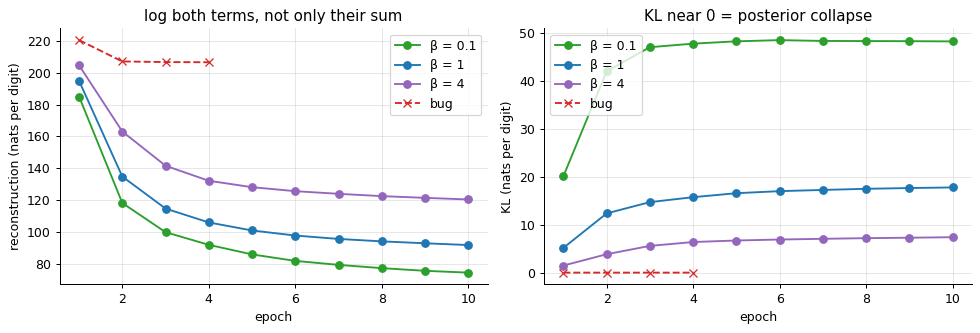

total run time of the notebook: 2.9 min on cpu


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ep = np.arange(1, 11)
for b, c in zip(betas, ["tab:green", "tab:blue", "tab:purple"]):
    axes[0].plot(ep, hists[b][:, 0], "o-", color=c, label=f"β = {b:g}")
    axes[1].plot(ep, hists[b][:, 1], "o-", color=c, label=f"β = {b:g}")
axes[0].plot(np.arange(1, len(hist_bug) + 1), hist_bug[:, 0], "x--", color="tab:red", label="bug")
axes[1].plot(np.arange(1, len(hist_bug) + 1), hist_bug[:, 1], "x--", color="tab:red", label="bug")
axes[0].set_ylabel("reconstruction (nats per digit)"); axes[1].set_ylabel("KL (nats per digit)")
for ax in axes:
    ax.set_xlabel("epoch"); ax.legend()
axes[0].set_title("log both terms, not only their sum"); axes[1].set_title("KL near 0 = posterior collapse")
plt.tight_layout(); plt.show()
print(f"total run time of the notebook: {(time.time() - T_START) / 60:.1f} min on {device}")

## 13. Summary

- **Autoencoder**: $\mathbf{z} = f_\phi(\mathbf{x})$, $\hat{\mathbf{x}} = g_\theta(\mathbf{z})$, trained to rebuild its input. The loss is a negative log-likelihood: MSE ↔ Gaussian pixels, BCE ↔ Bernoulli pixels.
- **PCA**: the top-$k$ eigenvectors of $\mathbf{C} = \frac{1}{n}\mathbf{X}_c^\top\mathbf{X}_c$, i.e. the right singular vectors of $\mathbf{X}_c$, with $\lambda_j = s_j^2/n$. Maximum variance = minimum squared error $= \sum_{j > k}\lambda_j$. MNIST: 87 components for 90% of the variance.
- **Linear autoencoder** = the PCA subspace (largest principal angle 0.56° after 10 epochs), but not the PC basis: $(\mathbf{W}_e\mathbf{A}, \mathbf{A}^{-1}\mathbf{W}_d)$ is equivalent for any invertible $\mathbf{A}$.
- **Non-linear autoencoder**: lower error at every $k$ (0.0211 at $k = 8$ = PCA with 24 components) and better codes (15-NN accuracy 73.8% vs 45.0% in 2-D).
- **Overcomplete codes** can learn the identity, $\mathrm{ReLU}(\mathbf{x}) - \mathrm{ReLU}(-\mathbf{x}) = \mathbf{x}$; sparsity (L1: 4.8% active units) or noise rules it out. **Denoising**: noisy input, clean target (MSE 0.0148 vs 0.1107 for a plain AE at $\sigma = 0.5$). A **transposed convolution** is the transpose of a convolution; uneven overlaps give checkerboards.
- **An autoencoder is not generative**: its codes have holes (50% of the 2-D box is empty), no density (wrong class proportions, total variation 0.25) and no scale (decoded $\mathcal{N}(\mathbf{0}, \mathbf{I})$ samples: 2% confident).
- **VAE**: $p(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I})$, $p_\theta(\mathbf{x} \mid \mathbf{z})$, $q_\phi(\mathbf{z} \mid \mathbf{x}) = \mathcal{N}(\boldsymbol{\mu}, \operatorname{diag}\boldsymbol{\sigma}^2)$. $\log p_\theta(\mathbf{x}) = \mathcal{L} + \mathrm{KL}(q \,\Vert\, p_\theta(\mathbf{z} \mid \mathbf{x}))$, with $\mathcal{L} = \mathbb{E}_q[\log p_\theta(\mathbf{x} \mid \mathbf{z})] - \mathrm{KL}(q \,\Vert\, p(\mathbf{z}))$ and $\mathrm{KL} = \frac{1}{2}\sum_j(\mu_j^2 + \sigma_j^2 - 1 - \log\sigma_j^2)$. Reparameterisation: $\mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \boldsymbol{\epsilon}$.
- **Numbers**: 2-D VAE ELBO −146.0 nats (0.269 bits per pixel); exact gaps 0.47 nats for a 0 and 8.58 for a 5 whose posterior lies elsewhere; 16-D VAE −108.5 nats (0.200 bits per pixel), 10 active dimensions, prior samples 45% confident (AE with $\mathcal{N}(\mathbf{0}, \mathbf{I})$: 2%).
- **β-VAE**: β trades rate for distortion (β = 0.1: R 48.6, D 73.0; β = 4: R 7.4, D 119.3); only β = 1 is the ELBO. **Posterior collapse**: KL → 0 and the code is ignored; averaging the BCE over pixels is β = 784.
- **Conditional VAE**: condition encoder and decoder on $y$; the code becomes a style space (99.8% of the generated digits are the requested ones).

## Exercises

Try each one before opening the answer.

1. **PCA by hand.** For the six points of section 2, compute the code and the reconstruction of $(6, 6)$ and of $(1, 4)$ with $k = 1$. Check that the mean squared error over the six points is $\lambda_2 = 1$.
2. **The linear autoencoder's basis.** (a) Show that $(\mathbf{W}_e\mathbf{A}, \mathbf{A}^{-1}\mathbf{W}_d)$ gives the same reconstructions as $(\mathbf{W}_e, \mathbf{W}_d)$ for any invertible $\mathbf{A}$. (b) How can you recover the principal components and their eigenvalues from the trained linear autoencoder of section 3? Try it.
3. **KL by hand.** With $\mathrm{KL}(\mathcal{N}(\mu_1, \sigma_1^2) \,\Vert\, \mathcal{N}(\mu_2, \sigma_2^2)) = \log\frac{\sigma_2}{\sigma_1} + \frac{\sigma_1^2 + (\mu_1 - \mu_2)^2}{2\sigma_2^2} - \frac{1}{2}$, compute both directions for $\mathcal{N}(1, 0.5^2)$ and $\mathcal{N}(0, 1)$. Which direction punishes $q$ for leaving out regions where $p$ has mass? Relate it to the 5 of section 8.
4. **Gradients of the KL.** For one latent dimension with encoder outputs $\mu$ and $s = \log\sigma^2$, compute $\partial\,\mathrm{KL}/\partial\mu$ and $\partial\,\mathrm{KL}/\partial s$. Where are they zero? What happens to the gradient if the network outputs $\sigma$ directly and $\sigma \to 0$?
5. **Score function vs reparameterisation.** For $z \sim \mathcal{N}(\mu, 1)$ and $h(z) = z^2$, show that the estimators $2z$ and $z^2(z - \mu)$ of $\frac{d}{d\mu}\mathbb{E}[h(z)]$ are both unbiased, and compute their variances per sample at $\mu = 1$. Check by simulation with 10 samples per estimate.
6. **Bookkeeping and warm-up.** (a) If the reconstruction term is averaged over the 784 pixels and the KL is averaged over the 16 latent dimensions, which β is effectively used? (b) Would a KL warm-up (β from 0 to its value over the first epochs) save the buggy loss of section 10? Explain with the rate–distortion picture.
7. **An anomaly score.** Compute $-\mathcal{L}(\mathbf{x})$ with the 16-D VAE for the binarised test digits and for 1000 binarised images of uniform noise. Why is $-\mathcal{L}$ a reasonable anomaly score? Why might it fail on images that are simple but are not digits, such as an all-white image? (Extra 5 develops this.)

<details>
<summary><b>Answers</b></summary>

**1.** Centred, $(6, 6) \to (3, 2)$: code $z = (3 + 2)/\sqrt{2} = 3.536$, reconstruction $(3, 4) + 3.536\,(0.707, 0.707) = (5.5, 6.5)$, squared error $0.5^2 + 0.5^2 = 0.5$. $(1, 4) \to (-2, 0)$: $z = -1.414$, reconstruction $(3, 4) - (1, 1) = (2, 3)$, squared error $1 + 1 = 2$. The residual of each point is its coordinate along $\mathbf{v}_2 = (-1, 1)/\sqrt{2}$: $-0.707, 1.414, -0.707, 1.414, -0.707, -0.707$, whose squares $0.5, 2, 0.5, 2, 0.5, 0.5$ have mean $6/6 = 1 = \lambda_2$.

**2.** (a) $\mathbf{x}(\mathbf{W}_e\mathbf{A})(\mathbf{A}^{-1}\mathbf{W}_d) = \mathbf{x}\mathbf{W}_e\mathbf{W}_d$. The loss depends only on the product, so training cannot prefer one $\mathbf{A}$, and the codes $\mathbf{x}\mathbf{W}_e\mathbf{A}$ can be any invertible mix of the PC scores. (b) At the optimum the reconstructions are the PCA projections, $\hat{\mathbf{X}} = \mathbf{X}_c\mathbf{V}_k\mathbf{V}_k^\top$, whose covariance $\mathbf{V}_k\,\mathrm{diag}(\lambda_1, \dots, \lambda_k)\,\mathbf{V}_k^\top$ has exactly the top-$k$ components as eigenvectors. So run a PCA on the reconstructions: `_, S_, Vh_ = torch.linalg.svd(lin_ae(Xc).detach(), full_matrices=False)`, then compare `(Vh_[:16] * Vh[:16]).sum(1).abs()` with 1 and `S_[:16]**2 / n` with `lam[:16]`. The well-separated components come back almost exactly; pairs with nearly equal eigenvalues (such as 13 and 14, 0.905 and 0.892) can come back mixed, which is what the remaining 0.5° allows.

**3.** $\mathrm{KL}(\mathcal{N}(1, 0.25) \,\Vert\, \mathcal{N}(0, 1)) = \log 2 + \frac{0.25 + 1}{2} - \frac{1}{2} = 0.693 + 0.625 - 0.5 = 0.818$. $\mathrm{KL}(\mathcal{N}(0, 1) \,\Vert\, \mathcal{N}(1, 0.25)) = \log 0.5 + \frac{1 + 1}{0.5} - \frac{1}{2} = -0.693 + 4 - 0.5 = 2.807$. $\mathrm{KL}(q \,\Vert\, p)$ averages $\log(q/p)$ over $q$: it is large only where $q$ has mass and $p$ has little, so a narrow $q$ inside $p$ is cheap ("mode seeking"). $\mathrm{KL}(p \,\Vert\, q)$ averages over $p$ and punishes $q$ for missing regions where $p$ has mass ("mass covering"): the narrow Gaussian misses the tails of $\mathcal{N}(0, 1)$. The ELBO's gap is $\mathrm{KL}(q \,\Vert\, p(\mathbf{z} \mid \mathbf{x}))$, the mode-seeking direction: nothing forces $q$ to cover all of the posterior, which is how $q$ for the 5 of section 8 can sit where the posterior has only 0.5% of its mass (it still pays: the gap is 8.58 nats).

**4.** $\mathrm{KL} = \frac{1}{2}(\mu^2 + e^s - 1 - s)$, so $\partial\,\mathrm{KL}/\partial\mu = \mu$ (zero at $\mu = 0$) and $\partial\,\mathrm{KL}/\partial s = \frac{1}{2}(e^s - 1)$ (zero at $s = 0$, i.e. $\sigma = 1$). Both are smooth and finite for every real $s$, and for very negative $s$ the second tends to $-\frac{1}{2}$. If the network outputs $\sigma$, then $\mathrm{KL} = \frac{1}{2}(\mu^2 + \sigma^2 - 1) - \log\sigma$ and $\partial\,\mathrm{KL}/\partial\sigma = \sigma - 1/\sigma \to -\infty$ as $\sigma \to 0$: exploding gradients, and any $\sigma \le 0$ (possible after an update) makes $\log\sigma$ NaN.

**5.** Reparameterised: $z = \mu + \epsilon$, $\frac{d}{d\mu}z^2 = 2z$, and $\mathbb{E}[2z] = 2\mu$, the true derivative of $\mathbb{E}[z^2] = \mu^2 + 1$; $\mathrm{Var}[2z] = 4$. Score function: $\nabla_\mu\log q = z - \mu = \epsilon$, and $\mathbb{E}[(\mu + \epsilon)^2\epsilon] = \mathbb{E}[\mu^2\epsilon + 2\mu\epsilon^2 + \epsilon^3] = 2\mu$ (odd moments vanish). At $\mu = 1$ the estimator is $\epsilon + 2\epsilon^2 + \epsilon^3$, with second moment $\mathbb{E}[\epsilon^2] + 4\mathbb{E}[\epsilon^4] + \mathbb{E}[\epsilon^6] + 2\cdot 2\,\mathbb{E}[\epsilon^3] + 2\,\mathbb{E}[\epsilon^4] + 2\cdot 2\,\mathbb{E}[\epsilon^5] = 1 + 12 + 15 + 0 + 6 + 0 = 34$, so the variance is $34 - 4 = 30$. With 10 samples the standard deviations are $2/\sqrt{10} = 0.63$ and $\sqrt{30}/\sqrt{10} = 1.73$:
```python
e = torch.randn(100000, 10); z = 1 + e
print((2 * z).mean(1).std(), (z**2 * e).mean(1).std())   # about 0.63 and 1.73
```

**6.** (a) The loss is $\frac{1}{784}D + \frac{1}{16}R = \frac{1}{784}(D + 49R)$: β = 49, still far too strong. (b) No. A warm-up fixes collapse caused by the **optimisation** (a KL that dominates before the decoder has learned to use the code). Here the collapsed model is the true optimum of the buggy objective: at the optimum of $D + \beta R$ the slope of the rate–distortion curve is $-\beta$, and one nat of rate never saves 784 nats of distortion (in section 10, going from β = 4 to β = 1 buys 29 nats of distortion for 10.8 nats of rate, under 3 per nat). Once β reaches 784 the code is switched off again. The fix is the bookkeeping, not the schedule.

**7.** The VAE was trained to give digits a high ELBO. Binarised noise has about half of its pixels black in random places; the decoder cannot predict them, so the reconstruction term costs hundreds of nats more than a digit, and $-\mathcal{L}$ flags it. The same mechanism detects odd digits, defects or fraudulent claims in other data: inputs far from the training distribution are expensive to encode. But a likelihood also measures **simplicity**: an all-white image has no black pixels, the decoder's background already predicts white almost everywhere, and $-\mathcal{L}$ can be **lower** than for a real digit. Likelihood models are known to rate simple out-of-distribution inputs as more likely than the training data (Nalisnick et al., 2019); remedies compare likelihoods with a reference model or test for typicality. Extra 5 builds anomaly detectors on reconstruction error and discusses these pitfalls.

</details>